In [1]:
import random
import time
from datetime import datetime
import collections
import csv

# Numerical and data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Network analysis
import networkx as nx

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score,  roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F

# PyTorch Geometric
from torch_geometric.data import Data, HeteroData
from torch_geometric.utils import from_networkx
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    HeteroConv,
    GATv2Conv,
    TransformerConv,
    GCNConv,
    MessagePassing
)
from collections import Counter, defaultdict

#optuna
import optuna

/home/rshrestha1/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=10, dropout=0.1):
        super().__init__()
        self.gat1 = TransformerConv(in_channels, hidden_channels, heads=10, concat=False, dropout=dropout)
        self.gat2 = TransformerConv(hidden_channels, out_channels, heads=10, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x

class NodeClassifier(nn.Module):
    def __init__(self, out_channels, num_classes):
        super().__init__()
        self.dropout = nn.Dropout(0.01)
        self.fc = nn.Linear(out_channels * 3 + 12, out_channels)
        self.fc1 = nn.Linear(out_channels, num_classes)

    def forward(self, x):
        x = self.fc(x)
        x = self.dropout(x)
        return self.fc1(x)

In [3]:
def train_model(encoder, classifier, data, optimizer, criterion, device):
    encoder.train()
    classifier.train()
    optimizer.zero_grad()
    data = data.to(device)

    x_dict, edge_index_dict = data['company'].x, data[('company','self','company')].edge_index
    
    y = data['company'].y
    train_mask = data['company'].train_mask

    x_dict = x_dict.to(device)
    edge_index_dict = edge_index_dict.to(device)
    y = y.to(device)

    node_repr = encoder(x_dict, edge_index_dict)
    logits = node_repr

    loss = criterion(logits[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.softmax(logits[train_mask], dim=1)
        preds = logits[train_mask].argmax(dim=1)

        y_true = y[train_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[train_mask])) > 1 else 0.0

    return loss.item(), acc, f1


def validate_model(encoder, classifier, data, criterion, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict = data['company'].x, data[('company','self','company')].edge_index
        y = data['company'].y
        val_mask = data['company'].val_mask

        x_dict = x_dict.to(device)
        edge_index_dict = edge_index_dict.to(device)
        y = y.to(device)

        node_repr = encoder(x_dict, edge_index_dict)
        
        logits = node_repr

        loss = criterion(logits[val_mask], y[val_mask])
        probs = torch.softmax(logits[val_mask], dim=1)
        preds = logits[val_mask].argmax(dim=1)

        y_true = y[val_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[val_mask])) > 1 else 0.0

    return loss.item(), acc, f1


def test_model(encoder, classifier, data, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict = data['company'].x, data[('company','self','company')].edge_index
        y = data['company'].y
        test_mask = data['company'].test_mask  # use test_mask if available

        x_dict = x_dict.to(device)
        edge_index_dict = edge_index_dict.to(device)
        y = y.to(device)

        node_repr = encoder(x_dict, edge_index_dict)
        
        logits = node_repr

        probs = torch.softmax(logits[test_mask], dim=1)
        preds = logits[test_mask].argmax(dim=1)

        y_true = y[test_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[test_mask])) > 1 else 0.0

    return acc, f1

In [4]:
def train_test(encoder, classifier, data, optimizer, criterion, device, epochs=1000, patience=100):
    best_val_loss = float('inf')
    counter = 0
    best_encoder = None
    best_classifier = None
    best_train_acc = None
    best_f1 = None

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_f1s, val_f1s = [], []

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_model(encoder, classifier, data, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = validate_model(encoder, classifier, data, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch: {epoch+1:03d}, '
                  f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_f1 = val_f1
            counter = 0
            best_encoder = encoder.state_dict()
            best_classifier = classifier.state_dict()
        else:
            counter += 1
            if counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")

    if best_encoder is not None and best_classifier is not None:
        encoder.load_state_dict(best_encoder)
        classifier.load_state_dict(best_classifier)

    return encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, best_val_loss, best_train_acc, best_f1

In [5]:
def run_experiment(year, metric, hidden_channels=64, out_channels=32, num_heads=4,
                   lr=0.01, weight_decay=5e-4, epochs=1000, patience=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    data = torch.load(f'Dataset/heterographdata{year}1.pt', weights_only=False)
    in_channels = data['company'].x.size(1)
    num_classes = int(data['company'].y.max().item()) + 1

    # print(data['company'].x)
    if torch.min(data['company'].y) < 0:
        valid_labels = data['company'].y >= 0
        num_classes = int(data['company'].y[valid_labels].max().item()) + 1

    print(f"Input channels: {in_channels}, Number of classes: {num_classes}")
    
    encoder = GAT(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels
    ).to(device)

    classifier = NodeClassifier(
        out_channels=out_channels,
        num_classes=num_classes
    ).to(device)

    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(classifier.parameters()), 
        lr=lr, weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss()

    encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, _, best_train_acc, best_f1 = train_test(
        encoder, classifier, data, optimizer, criterion, device, epochs=epochs, patience=patience
    )

    test_acc, test_f1 = test_model(encoder, classifier, data, device)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1 Score: {test_f1:.4f}')

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'Graph_EncoderClassifier_training_{year}_{metric}.png')
    plt.show()

    return {
        'encoder': encoder,
        'classifier': classifier,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'training_time': training_time,
        'epochs_run': len(train_losses),
        'best_train_acc': best_train_acc
    }


========== Run 1 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2783, Val Loss: 3.1762, Train Acc: 0.1684, Val Acc: 0.2406
Epoch: 020, Train Loss: 2.8492, Val Loss: 2.7375, Train Acc: 0.5093, Val Acc: 0.5301
Epoch: 030, Train Loss: 2.4156, Val Loss: 2.3171, Train Acc: 0.5077, Val Acc: 0.5526
Epoch: 040, Train Loss: 1.9652, Val Loss: 1.8779, Train Acc: 0.5310, Val Acc: 0.5451
Epoch: 050, Train Loss: 1.5252, Val Loss: 1.4574, Train Acc: 0.5512, Val Acc: 0.5639
Epoch: 060, Train Loss: 1.1810, Val Loss: 1.1310, Train Acc: 0.5600, Val Acc: 0.5977
Epoch: 070, Train Loss: 0.9657, Val Loss: 0.9320, Train Acc: 0.5778, Val Acc: 0.6090
Epoch: 080, Train Loss: 0.8534, Val Loss: 0.8284, Train Acc: 0.5898, Val Acc: 0.6278
Epoch: 090, Train Loss: 0.7865, Val Loss: 0.7769, Train Acc: 0.6068, Val Acc: 0.6466
Epoch: 100, Train Loss: 0.7518, Val Loss: 0.7513, Train Acc: 0.5850, Val Acc: 0.6429
Epoch: 110, Train Loss

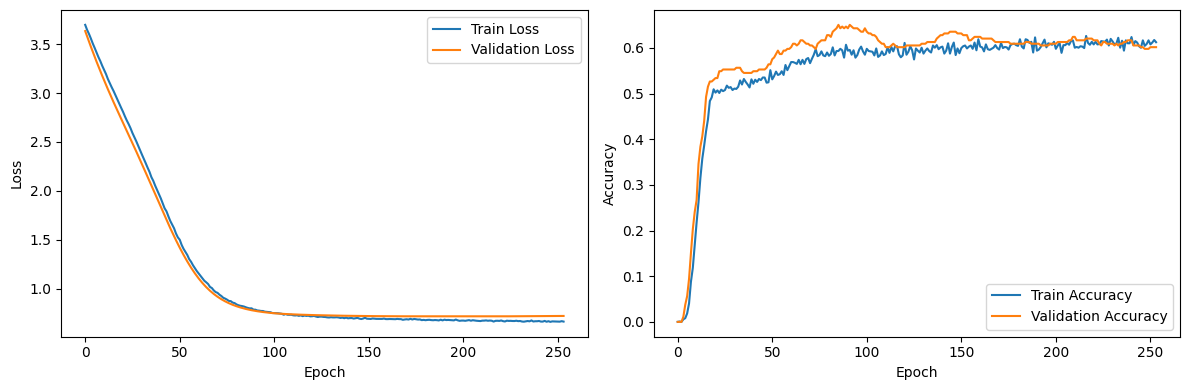


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0348, Val Loss: 3.0363, Train Acc: 0.4815, Val Acc: 0.4980
Epoch: 020, Train Loss: 2.6440, Val Loss: 2.6765, Train Acc: 0.5076, Val Acc: 0.4941
Epoch: 030, Train Loss: 2.2584, Val Loss: 2.2932, Train Acc: 0.5042, Val Acc: 0.4941
Epoch: 040, Train Loss: 1.8722, Val Loss: 1.8953, Train Acc: 0.5126, Val Acc: 0.4902
Epoch: 050, Train Loss: 1.4997, Val Loss: 1.5164, Train Acc: 0.5201, Val Acc: 0.5059
Epoch: 060, Train Loss: 1.2084, Val Loss: 1.2064, Train Acc: 0.5193, Val Acc: 0.5137
Epoch: 070, Train Loss: 0.9910, Val Loss: 0.9970, Train Acc: 0.5344, Val Acc: 0.5216
Epoch: 080, Train Loss: 0.8748, Val Loss: 0.8740, Train Acc: 0.5537, Val Acc: 0.5608
Epoch: 090, Train Loss: 0.8072, Val Loss: 0.8056, Train Acc: 0.5587, Val Acc: 0.5843
Epoch: 100, Train Loss: 0.7665, Val Loss: 0.7670, Train Acc: 0.5688, Val Acc: 0.5608
Epoch: 110, Train Loss: 0.7428, Val Loss: 0.7439, Tr

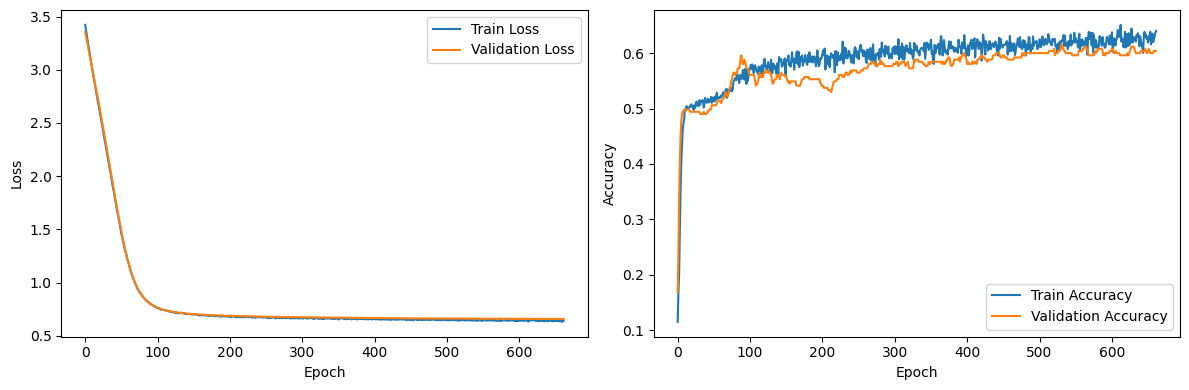


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1174, Val Loss: 3.0491, Train Acc: 0.4809, Val Acc: 0.4915
Epoch: 020, Train Loss: 2.7175, Val Loss: 2.6438, Train Acc: 0.4991, Val Acc: 0.5042
Epoch: 030, Train Loss: 2.3031, Val Loss: 2.2355, Train Acc: 0.5073, Val Acc: 0.4958
Epoch: 040, Train Loss: 1.8677, Val Loss: 1.8129, Train Acc: 0.5073, Val Acc: 0.5000
Epoch: 050, Train Loss: 1.4660, Val Loss: 1.4204, Train Acc: 0.5064, Val Acc: 0.5000
Epoch: 060, Train Loss: 1.1513, Val Loss: 1.1227, Train Acc: 0.5209, Val Acc: 0.5042
Epoch: 070, Train Loss: 0.9566, Val Loss: 0.9419, Train Acc: 0.5445, Val Acc: 0.5085
Epoch: 080, Train Loss: 0.8461, Val Loss: 0.8459, Train Acc: 0.5563, Val Acc: 0.5042
Epoch: 090, Train Loss: 0.7908, Val Loss: 0.7959, Train Acc: 0.5771, Val Acc: 0.5254
Epoch: 100, Train Loss: 0.7551, Val Loss: 0.7683, Train Acc: 0.5871, Val Acc: 0.5339
Epoch: 110, Train Loss: 0.7339, Val Loss: 0.7517, Tr

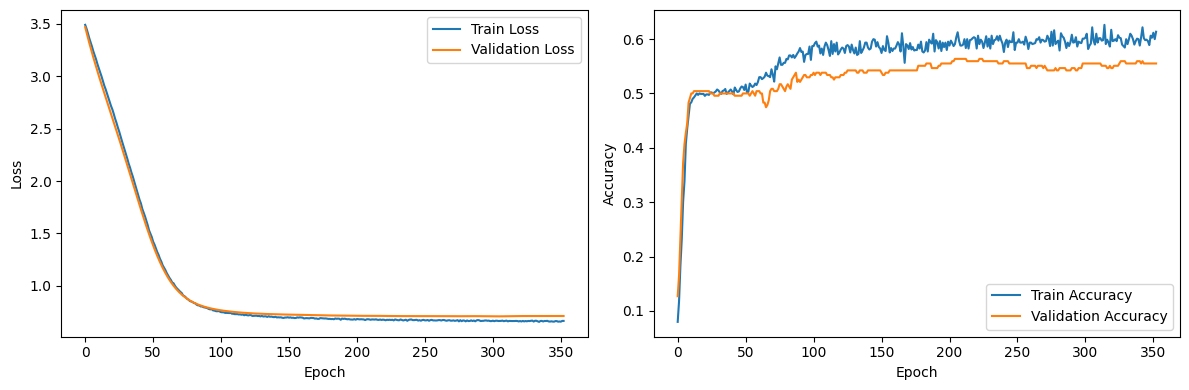


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2898, Val Loss: 3.2137, Train Acc: 0.2461, Val Acc: 0.3761
Epoch: 020, Train Loss: 2.9175, Val Loss: 2.8140, Train Acc: 0.5315, Val Acc: 0.5138
Epoch: 030, Train Loss: 2.5283, Val Loss: 2.4254, Train Acc: 0.5108, Val Acc: 0.5183
Epoch: 040, Train Loss: 2.1029, Val Loss: 2.0167, Train Acc: 0.5266, Val Acc: 0.4908
Epoch: 050, Train Loss: 1.6745, Val Loss: 1.6127, Train Acc: 0.5226, Val Acc: 0.4954
Epoch: 060, Train Loss: 1.3066, Val Loss: 1.2771, Train Acc: 0.5256, Val Acc: 0.5138
Epoch: 070, Train Loss: 1.0588, Val Loss: 1.0511, Train Acc: 0.5335, Val Acc: 0.5000
Epoch: 080, Train Loss: 0.9159, Val Loss: 0.9202, Train Acc: 0.5551, Val Acc: 0.4908
Epoch: 090, Train Loss: 0.8360, Val Loss: 0.8462, Train Acc: 0.5620, Val Acc: 0.4771
Epoch: 100, Train Loss: 0.8045, Val Loss: 0.8018, Train Acc: 0.5413, Val Acc: 0.4817
Epoch: 110, Train Loss: 0.7663, Val Loss: 0.7736, Tr

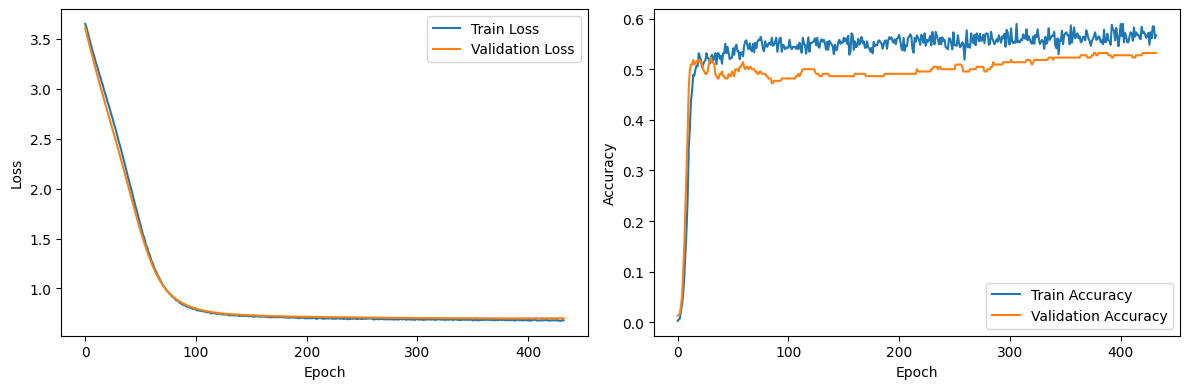


========== Run 2 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1033, Val Loss: 3.0484, Train Acc: 0.3465, Val Acc: 0.4549
Epoch: 020, Train Loss: 2.7165, Val Loss: 2.6609, Train Acc: 0.5318, Val Acc: 0.5414
Epoch: 030, Train Loss: 2.3223, Val Loss: 2.2774, Train Acc: 0.5383, Val Acc: 0.5526
Epoch: 040, Train Loss: 1.9127, Val Loss: 1.8771, Train Acc: 0.5488, Val Acc: 0.5602
Epoch: 050, Train Loss: 1.5171, Val Loss: 1.4919, Train Acc: 0.5528, Val Acc: 0.5752
Epoch: 060, Train Loss: 1.1963, Val Loss: 1.1802, Train Acc: 0.5633, Val Acc: 0.5902
Epoch: 070, Train Loss: 0.9914, Val Loss: 0.9777, Train Acc: 0.5560, Val Acc: 0.5827
Epoch: 080, Train Loss: 0.8683, Val Loss: 0.8665, Train Acc: 0.5713, Val Acc: 0.5865
Epoch: 090, Train Loss: 0.7987, Val Loss: 0.8090, Train Acc: 0.5737, Val Acc: 0.5827
Epoch: 100, Train Loss: 0.7660, Val Loss: 0.7782, Train Acc: 0.5810, Val Acc: 0.5940
Epoch: 110, Train Loss

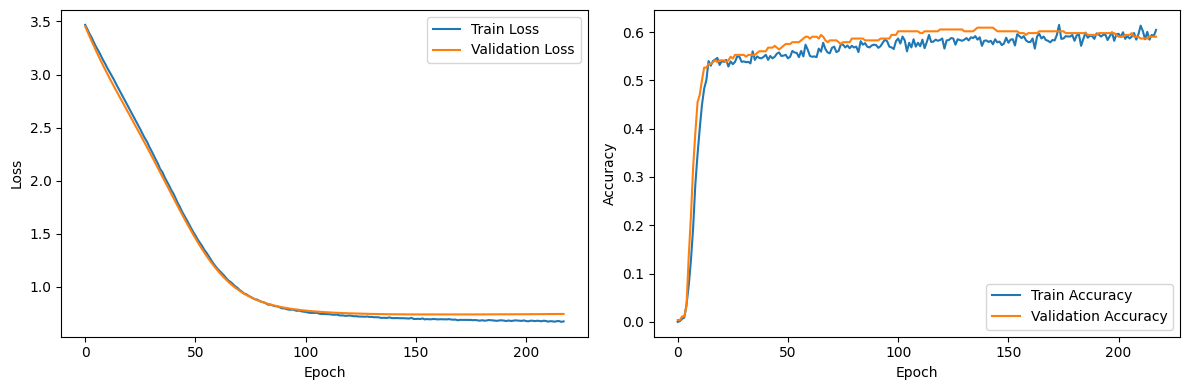


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1581, Val Loss: 3.1627, Train Acc: 0.3649, Val Acc: 0.4431
Epoch: 020, Train Loss: 2.7234, Val Loss: 2.7558, Train Acc: 0.5151, Val Acc: 0.5020
Epoch: 030, Train Loss: 2.3004, Val Loss: 2.3360, Train Acc: 0.5101, Val Acc: 0.4902
Epoch: 040, Train Loss: 1.8805, Val Loss: 1.9036, Train Acc: 0.5310, Val Acc: 0.4784
Epoch: 050, Train Loss: 1.4926, Val Loss: 1.4952, Train Acc: 0.5252, Val Acc: 0.4784
Epoch: 060, Train Loss: 1.1726, Val Loss: 1.1711, Train Acc: 0.5201, Val Acc: 0.4980
Epoch: 070, Train Loss: 0.9613, Val Loss: 0.9656, Train Acc: 0.5352, Val Acc: 0.5137
Epoch: 080, Train Loss: 0.8578, Val Loss: 0.8540, Train Acc: 0.5596, Val Acc: 0.5294
Epoch: 090, Train Loss: 0.7931, Val Loss: 0.7946, Train Acc: 0.5738, Val Acc: 0.5255
Epoch: 100, Train Loss: 0.7537, Val Loss: 0.7611, Train Acc: 0.5831, Val Acc: 0.5373
Epoch: 110, Train Loss: 0.7400, Val Loss: 0.7406, Tr

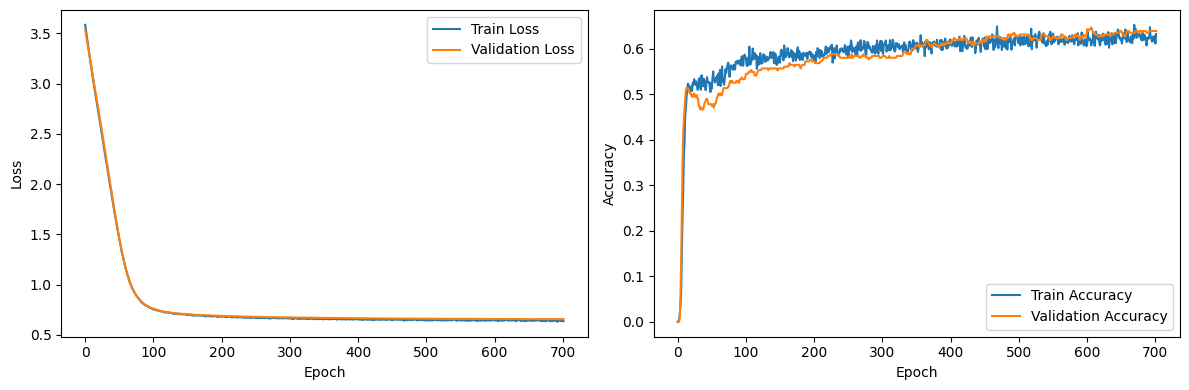


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2753, Val Loss: 3.2219, Train Acc: 0.0626, Val Acc: 0.1017
Epoch: 020, Train Loss: 2.9150, Val Loss: 2.8534, Train Acc: 0.5227, Val Acc: 0.5212
Epoch: 030, Train Loss: 2.5333, Val Loss: 2.4808, Train Acc: 0.5544, Val Acc: 0.5254
Epoch: 040, Train Loss: 2.1216, Val Loss: 2.0822, Train Acc: 0.5590, Val Acc: 0.5297
Epoch: 050, Train Loss: 1.7095, Val Loss: 1.6792, Train Acc: 0.5617, Val Acc: 0.5169
Epoch: 060, Train Loss: 1.3392, Val Loss: 1.3263, Train Acc: 0.5635, Val Acc: 0.5042
Epoch: 070, Train Loss: 1.0806, Val Loss: 1.0758, Train Acc: 0.5608, Val Acc: 0.5085
Epoch: 080, Train Loss: 0.9237, Val Loss: 0.9286, Train Acc: 0.5572, Val Acc: 0.5085
Epoch: 090, Train Loss: 0.8314, Val Loss: 0.8496, Train Acc: 0.5853, Val Acc: 0.5127
Epoch: 100, Train Loss: 0.7904, Val Loss: 0.8063, Train Acc: 0.5844, Val Acc: 0.5212
Epoch: 110, Train Loss: 0.7594, Val Loss: 0.7802, Tr

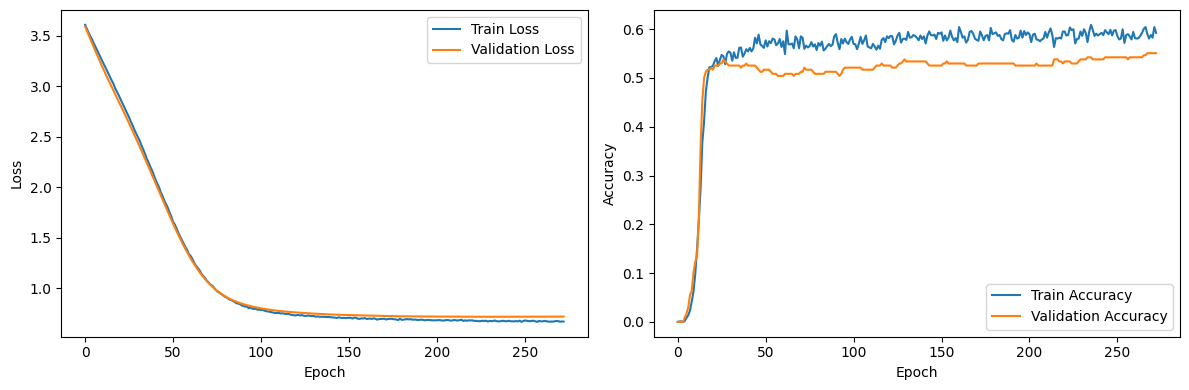


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0421, Val Loss: 2.9399, Train Acc: 0.4970, Val Acc: 0.4862
Epoch: 020, Train Loss: 2.6650, Val Loss: 2.5480, Train Acc: 0.5285, Val Acc: 0.4954
Epoch: 030, Train Loss: 2.2751, Val Loss: 2.1633, Train Acc: 0.5276, Val Acc: 0.5046
Epoch: 040, Train Loss: 1.8697, Val Loss: 1.7745, Train Acc: 0.5197, Val Acc: 0.5046
Epoch: 050, Train Loss: 1.4796, Val Loss: 1.4189, Train Acc: 0.5256, Val Acc: 0.5000
Epoch: 060, Train Loss: 1.1783, Val Loss: 1.1468, Train Acc: 0.5285, Val Acc: 0.5046
Epoch: 070, Train Loss: 0.9819, Val Loss: 0.9740, Train Acc: 0.5315, Val Acc: 0.5183
Epoch: 080, Train Loss: 0.8666, Val Loss: 0.8744, Train Acc: 0.5472, Val Acc: 0.5183
Epoch: 090, Train Loss: 0.8157, Val Loss: 0.8169, Train Acc: 0.5472, Val Acc: 0.5138
Epoch: 100, Train Loss: 0.7767, Val Loss: 0.7824, Train Acc: 0.5423, Val Acc: 0.5229
Epoch: 110, Train Loss: 0.7513, Val Loss: 0.7618, Tr

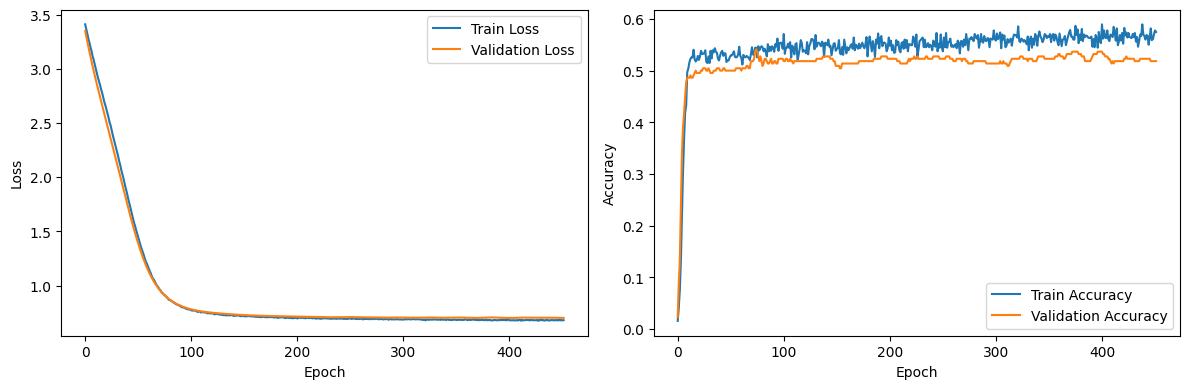


========== Run 3 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1620, Val Loss: 3.0735, Train Acc: 0.4956, Val Acc: 0.4887
Epoch: 020, Train Loss: 2.7537, Val Loss: 2.6551, Train Acc: 0.5020, Val Acc: 0.5000
Epoch: 030, Train Loss: 2.3497, Val Loss: 2.2488, Train Acc: 0.5004, Val Acc: 0.5075
Epoch: 040, Train Loss: 1.9372, Val Loss: 1.8368, Train Acc: 0.5028, Val Acc: 0.5150
Epoch: 050, Train Loss: 1.5381, Val Loss: 1.4526, Train Acc: 0.5117, Val Acc: 0.5150
Epoch: 060, Train Loss: 1.2114, Val Loss: 1.1542, Train Acc: 0.5278, Val Acc: 0.5075
Epoch: 070, Train Loss: 1.0017, Val Loss: 0.9695, Train Acc: 0.5318, Val Acc: 0.5338
Epoch: 080, Train Loss: 0.8793, Val Loss: 0.8745, Train Acc: 0.5512, Val Acc: 0.5714
Epoch: 090, Train Loss: 0.8051, Val Loss: 0.8255, Train Acc: 0.5616, Val Acc: 0.5827
Epoch: 100, Train Loss: 0.7737, Val Loss: 0.7936, Train Acc: 0.5576, Val Acc: 0.5789
Epoch: 110, Train Loss

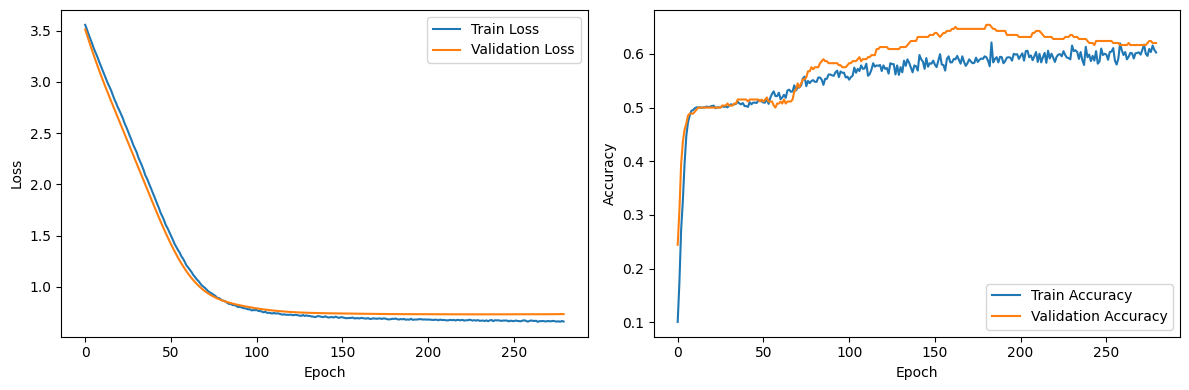


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3541, Val Loss: 3.3174, Train Acc: 0.0831, Val Acc: 0.1294
Epoch: 020, Train Loss: 2.9563, Val Loss: 2.9771, Train Acc: 0.5109, Val Acc: 0.4941
Epoch: 030, Train Loss: 2.5817, Val Loss: 2.6239, Train Acc: 0.5411, Val Acc: 0.5098
Epoch: 040, Train Loss: 2.1973, Val Loss: 2.2344, Train Acc: 0.5545, Val Acc: 0.5216
Epoch: 050, Train Loss: 1.7953, Val Loss: 1.8216, Train Acc: 0.5512, Val Acc: 0.5294
Epoch: 060, Train Loss: 1.4230, Val Loss: 1.4345, Train Acc: 0.5503, Val Acc: 0.5373
Epoch: 070, Train Loss: 1.1263, Val Loss: 1.1371, Train Acc: 0.5604, Val Acc: 0.5294
Epoch: 080, Train Loss: 0.9407, Val Loss: 0.9525, Train Acc: 0.5596, Val Acc: 0.5059
Epoch: 090, Train Loss: 0.8351, Val Loss: 0.8507, Train Acc: 0.5772, Val Acc: 0.5059
Epoch: 100, Train Loss: 0.7832, Val Loss: 0.7945, Train Acc: 0.5738, Val Acc: 0.4941
Epoch: 110, Train Loss: 0.7551, Val Loss: 0.7618, Tr

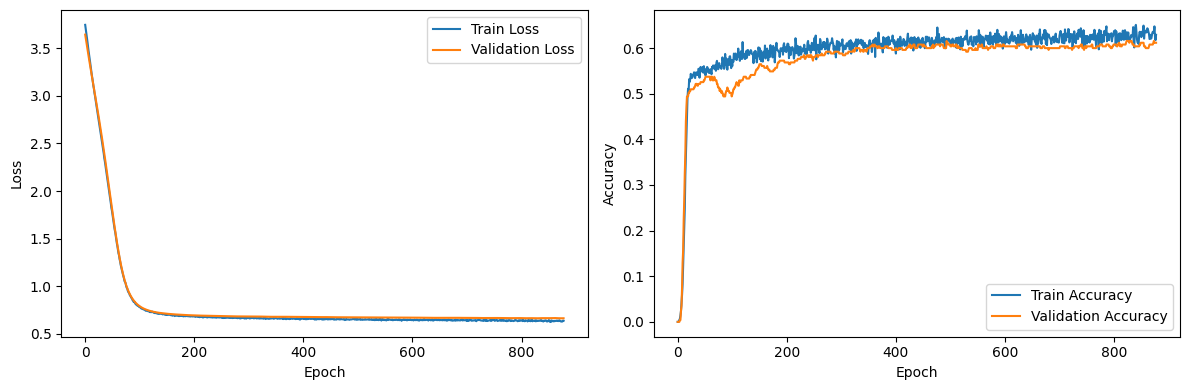


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3200, Val Loss: 3.2462, Train Acc: 0.1307, Val Acc: 0.2839
Epoch: 020, Train Loss: 2.9297, Val Loss: 2.8570, Train Acc: 0.5599, Val Acc: 0.5297
Epoch: 030, Train Loss: 2.5284, Val Loss: 2.4666, Train Acc: 0.5617, Val Acc: 0.5339
Epoch: 040, Train Loss: 2.0990, Val Loss: 2.0490, Train Acc: 0.5817, Val Acc: 0.5381
Epoch: 050, Train Loss: 1.6629, Val Loss: 1.6299, Train Acc: 0.5799, Val Acc: 0.5593
Epoch: 060, Train Loss: 1.2960, Val Loss: 1.2732, Train Acc: 0.5780, Val Acc: 0.5339
Epoch: 070, Train Loss: 1.0476, Val Loss: 1.0326, Train Acc: 0.5871, Val Acc: 0.5212
Epoch: 080, Train Loss: 0.8912, Val Loss: 0.8989, Train Acc: 0.5862, Val Acc: 0.5127
Epoch: 090, Train Loss: 0.8167, Val Loss: 0.8285, Train Acc: 0.5753, Val Acc: 0.5212
Epoch: 100, Train Loss: 0.7760, Val Loss: 0.7894, Train Acc: 0.5708, Val Acc: 0.5466
Epoch: 110, Train Loss: 0.7491, Val Loss: 0.7656, Tr

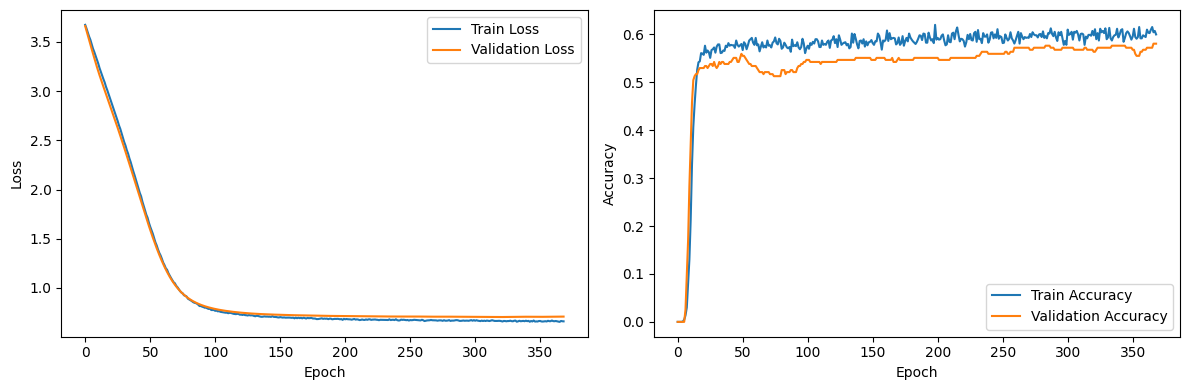


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1335, Val Loss: 3.0530, Train Acc: 0.4675, Val Acc: 0.5000
Epoch: 020, Train Loss: 2.7439, Val Loss: 2.6415, Train Acc: 0.5226, Val Acc: 0.5275
Epoch: 030, Train Loss: 2.3511, Val Loss: 2.2560, Train Acc: 0.5276, Val Acc: 0.5321
Epoch: 040, Train Loss: 1.9470, Val Loss: 1.8739, Train Acc: 0.5522, Val Acc: 0.4954
Epoch: 050, Train Loss: 1.5635, Val Loss: 1.5156, Train Acc: 0.5512, Val Acc: 0.5046
Epoch: 060, Train Loss: 1.2577, Val Loss: 1.2233, Train Acc: 0.5463, Val Acc: 0.5046
Epoch: 070, Train Loss: 1.0265, Val Loss: 1.0222, Train Acc: 0.5679, Val Acc: 0.5000
Epoch: 080, Train Loss: 0.9009, Val Loss: 0.9006, Train Acc: 0.5433, Val Acc: 0.5046
Epoch: 090, Train Loss: 0.8229, Val Loss: 0.8320, Train Acc: 0.5531, Val Acc: 0.5046
Epoch: 100, Train Loss: 0.7833, Val Loss: 0.7929, Train Acc: 0.5482, Val Acc: 0.5000
Epoch: 110, Train Loss: 0.7571, Val Loss: 0.7687, Tr

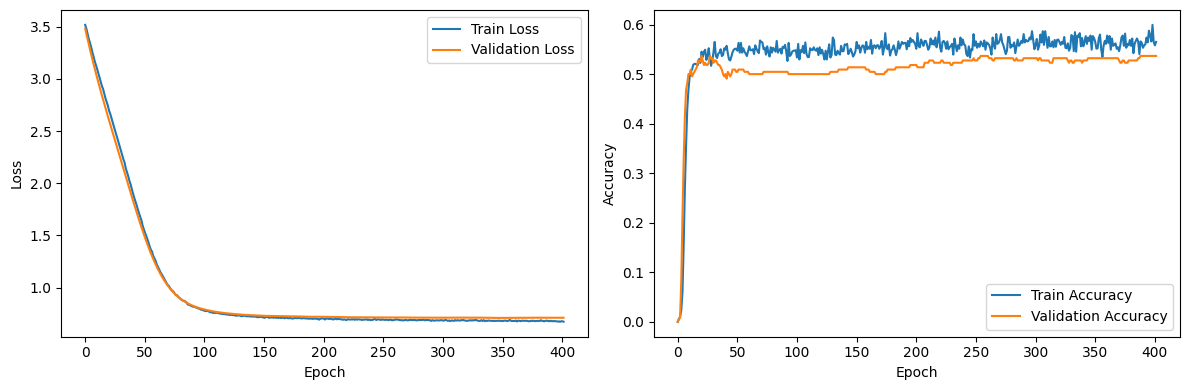


========== Run 4 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2677, Val Loss: 3.1973, Train Acc: 0.1563, Val Acc: 0.2406
Epoch: 020, Train Loss: 2.8591, Val Loss: 2.7577, Train Acc: 0.4980, Val Acc: 0.5263
Epoch: 030, Train Loss: 2.4442, Val Loss: 2.3451, Train Acc: 0.5020, Val Acc: 0.5301
Epoch: 040, Train Loss: 2.0246, Val Loss: 1.9311, Train Acc: 0.4996, Val Acc: 0.5263
Epoch: 050, Train Loss: 1.6183, Val Loss: 1.5420, Train Acc: 0.5044, Val Acc: 0.5338
Epoch: 060, Train Loss: 1.2898, Val Loss: 1.2270, Train Acc: 0.5214, Val Acc: 0.5226
Epoch: 070, Train Loss: 1.0525, Val Loss: 1.0158, Train Acc: 0.5351, Val Acc: 0.5301
Epoch: 080, Train Loss: 0.9199, Val Loss: 0.8926, Train Acc: 0.5552, Val Acc: 0.5677
Epoch: 090, Train Loss: 0.8283, Val Loss: 0.8240, Train Acc: 0.5624, Val Acc: 0.5639
Epoch: 100, Train Loss: 0.7852, Val Loss: 0.7841, Train Acc: 0.5560, Val Acc: 0.5677
Epoch: 110, Train Loss

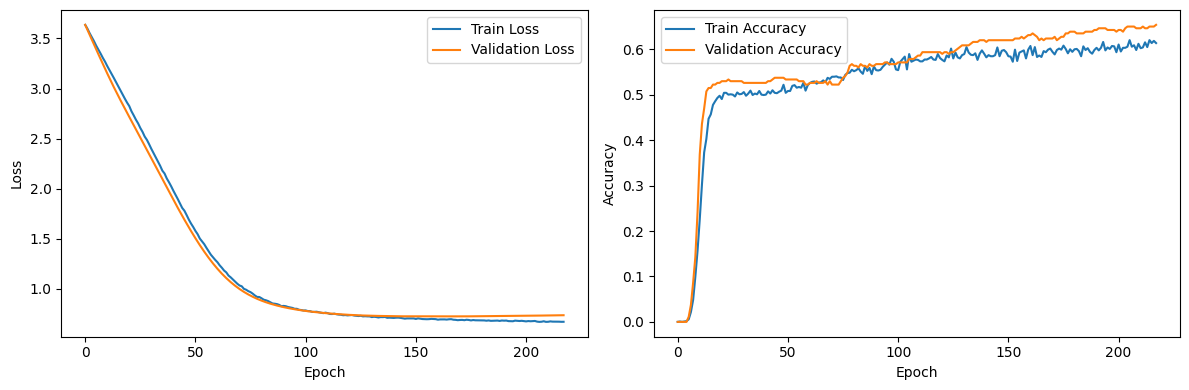


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0984, Val Loss: 3.0863, Train Acc: 0.2743, Val Acc: 0.3529
Epoch: 020, Train Loss: 2.6971, Val Loss: 2.7131, Train Acc: 0.5260, Val Acc: 0.4902
Epoch: 030, Train Loss: 2.2969, Val Loss: 2.3197, Train Acc: 0.5386, Val Acc: 0.4902
Epoch: 040, Train Loss: 1.8924, Val Loss: 1.9082, Train Acc: 0.5403, Val Acc: 0.4745
Epoch: 050, Train Loss: 1.5100, Val Loss: 1.5148, Train Acc: 0.5537, Val Acc: 0.4980
Epoch: 060, Train Loss: 1.1992, Val Loss: 1.1990, Train Acc: 0.5487, Val Acc: 0.4824
Epoch: 070, Train Loss: 0.9922, Val Loss: 0.9928, Train Acc: 0.5680, Val Acc: 0.4941
Epoch: 080, Train Loss: 0.8656, Val Loss: 0.8755, Train Acc: 0.5721, Val Acc: 0.5098
Epoch: 090, Train Loss: 0.8033, Val Loss: 0.8109, Train Acc: 0.5847, Val Acc: 0.5059
Epoch: 100, Train Loss: 0.7625, Val Loss: 0.7742, Train Acc: 0.5730, Val Acc: 0.5255
Epoch: 110, Train Loss: 0.7395, Val Loss: 0.7521, Tr

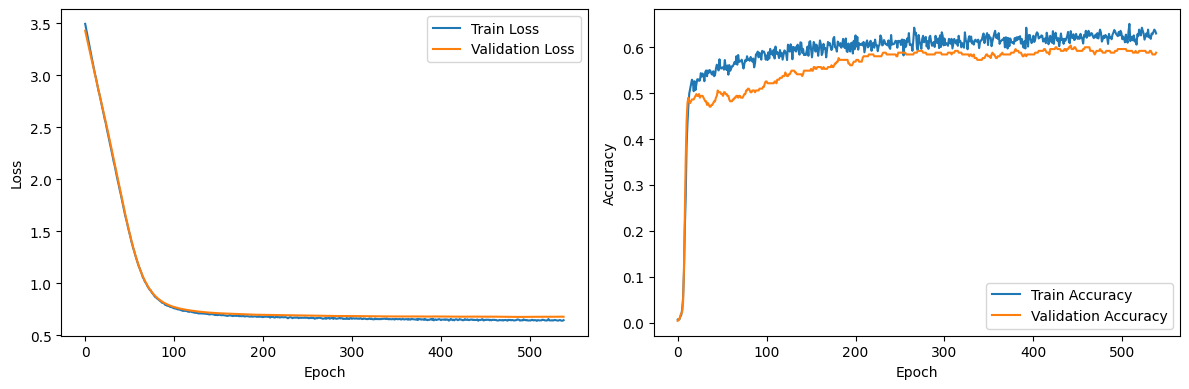


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9278, Val Loss: 2.8627, Train Acc: 0.5299, Val Acc: 0.4958
Epoch: 020, Train Loss: 2.5475, Val Loss: 2.4789, Train Acc: 0.5200, Val Acc: 0.4958
Epoch: 030, Train Loss: 2.1465, Val Loss: 2.0853, Train Acc: 0.5381, Val Acc: 0.5381
Epoch: 040, Train Loss: 1.7376, Val Loss: 1.6914, Train Acc: 0.5517, Val Acc: 0.5466
Epoch: 050, Train Loss: 1.3769, Val Loss: 1.3381, Train Acc: 0.5617, Val Acc: 0.5169
Epoch: 060, Train Loss: 1.1085, Val Loss: 1.0740, Train Acc: 0.5526, Val Acc: 0.5085
Epoch: 070, Train Loss: 0.9257, Val Loss: 0.9137, Train Acc: 0.5690, Val Acc: 0.5042
Epoch: 080, Train Loss: 0.8307, Val Loss: 0.8299, Train Acc: 0.5717, Val Acc: 0.5297
Epoch: 090, Train Loss: 0.7796, Val Loss: 0.7875, Train Acc: 0.5572, Val Acc: 0.5381
Epoch: 100, Train Loss: 0.7502, Val Loss: 0.7649, Train Acc: 0.5808, Val Acc: 0.5339
Epoch: 110, Train Loss: 0.7340, Val Loss: 0.7504, Tr

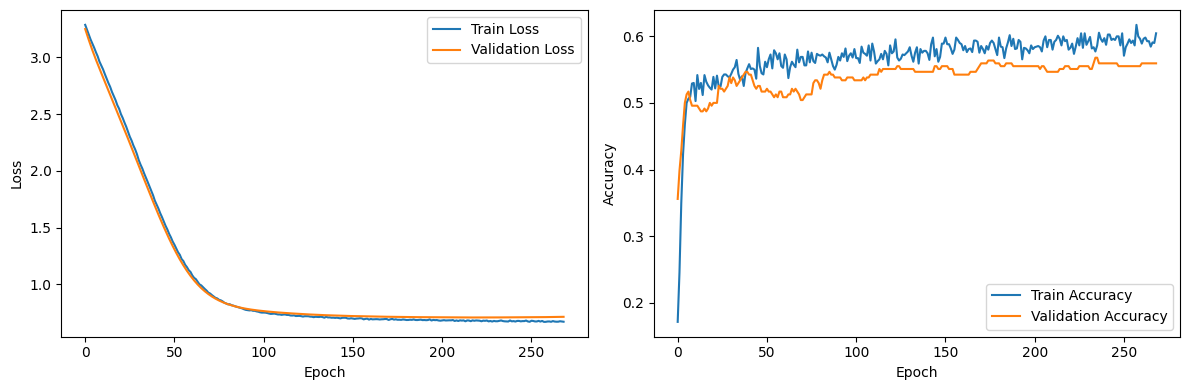


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1962, Val Loss: 3.0956, Train Acc: 0.2884, Val Acc: 0.4174
Epoch: 020, Train Loss: 2.7899, Val Loss: 2.6762, Train Acc: 0.5157, Val Acc: 0.5505
Epoch: 030, Train Loss: 2.3736, Val Loss: 2.2622, Train Acc: 0.5374, Val Acc: 0.5505
Epoch: 040, Train Loss: 1.9537, Val Loss: 1.8427, Train Acc: 0.5236, Val Acc: 0.5505
Epoch: 050, Train Loss: 1.5357, Val Loss: 1.4560, Train Acc: 0.5394, Val Acc: 0.5367
Epoch: 060, Train Loss: 1.2053, Val Loss: 1.1582, Train Acc: 0.5285, Val Acc: 0.5183
Epoch: 070, Train Loss: 0.9919, Val Loss: 0.9713, Train Acc: 0.5256, Val Acc: 0.5229
Epoch: 080, Train Loss: 0.8792, Val Loss: 0.8680, Train Acc: 0.5344, Val Acc: 0.5229
Epoch: 090, Train Loss: 0.8129, Val Loss: 0.8115, Train Acc: 0.5413, Val Acc: 0.5229
Epoch: 100, Train Loss: 0.7803, Val Loss: 0.7784, Train Acc: 0.5522, Val Acc: 0.5138
Epoch: 110, Train Loss: 0.7629, Val Loss: 0.7588, Tr

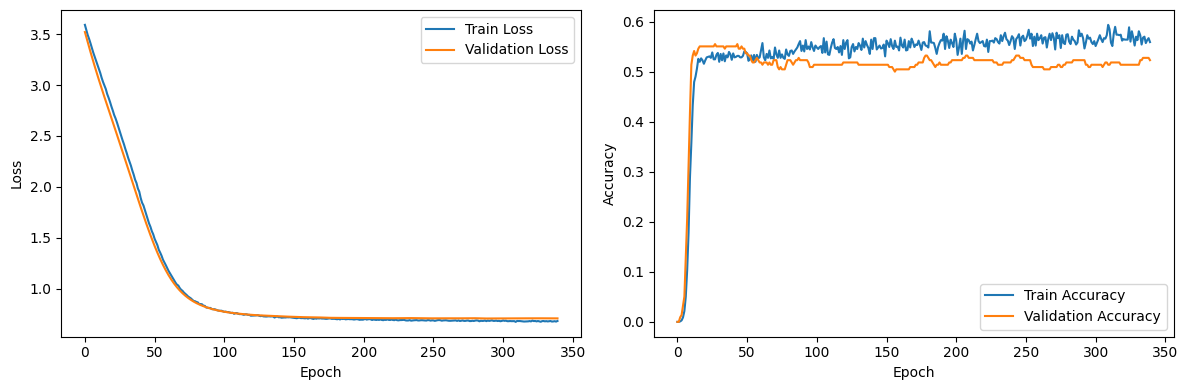


========== Run 5 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1914, Val Loss: 3.1303, Train Acc: 0.1853, Val Acc: 0.2105
Epoch: 020, Train Loss: 2.8396, Val Loss: 2.7655, Train Acc: 0.4835, Val Acc: 0.4699
Epoch: 030, Train Loss: 2.4795, Val Loss: 2.4147, Train Acc: 0.5133, Val Acc: 0.4624
Epoch: 040, Train Loss: 2.0919, Val Loss: 2.0350, Train Acc: 0.5004, Val Acc: 0.4549
Epoch: 050, Train Loss: 1.6922, Val Loss: 1.6426, Train Acc: 0.4875, Val Acc: 0.4699
Epoch: 060, Train Loss: 1.3350, Val Loss: 1.2914, Train Acc: 0.5133, Val Acc: 0.4774
Epoch: 070, Train Loss: 1.0656, Val Loss: 1.0376, Train Acc: 0.5149, Val Acc: 0.4699
Epoch: 080, Train Loss: 0.9175, Val Loss: 0.8886, Train Acc: 0.5173, Val Acc: 0.5000
Epoch: 090, Train Loss: 0.8263, Val Loss: 0.8090, Train Acc: 0.5657, Val Acc: 0.6128
Epoch: 100, Train Loss: 0.7787, Val Loss: 0.7678, Train Acc: 0.5576, Val Acc: 0.5940
Epoch: 110, Train Loss

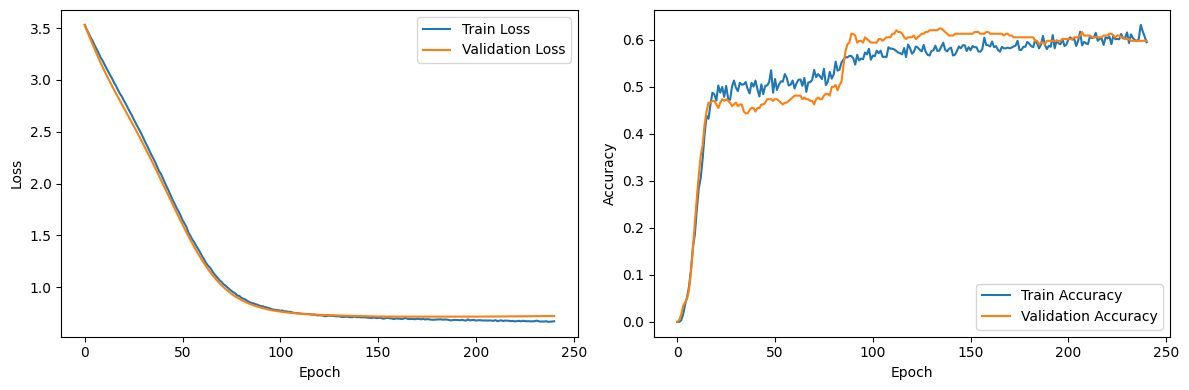


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2356, Val Loss: 3.2406, Train Acc: 0.1451, Val Acc: 0.1765
Epoch: 020, Train Loss: 2.8352, Val Loss: 2.8719, Train Acc: 0.5453, Val Acc: 0.5294
Epoch: 030, Train Loss: 2.4544, Val Loss: 2.4941, Train Acc: 0.5336, Val Acc: 0.5176
Epoch: 040, Train Loss: 2.0500, Val Loss: 2.0876, Train Acc: 0.5478, Val Acc: 0.5333
Epoch: 050, Train Loss: 1.6536, Val Loss: 1.6722, Train Acc: 0.5461, Val Acc: 0.5373
Epoch: 060, Train Loss: 1.2921, Val Loss: 1.3038, Train Acc: 0.5520, Val Acc: 0.5529
Epoch: 070, Train Loss: 1.0397, Val Loss: 1.0440, Train Acc: 0.5604, Val Acc: 0.5569
Epoch: 080, Train Loss: 0.8850, Val Loss: 0.8966, Train Acc: 0.5763, Val Acc: 0.5529
Epoch: 090, Train Loss: 0.8105, Val Loss: 0.8201, Train Acc: 0.5822, Val Acc: 0.5647
Epoch: 100, Train Loss: 0.7659, Val Loss: 0.7785, Train Acc: 0.5646, Val Acc: 0.5490
Epoch: 110, Train Loss: 0.7414, Val Loss: 0.7542, Tr

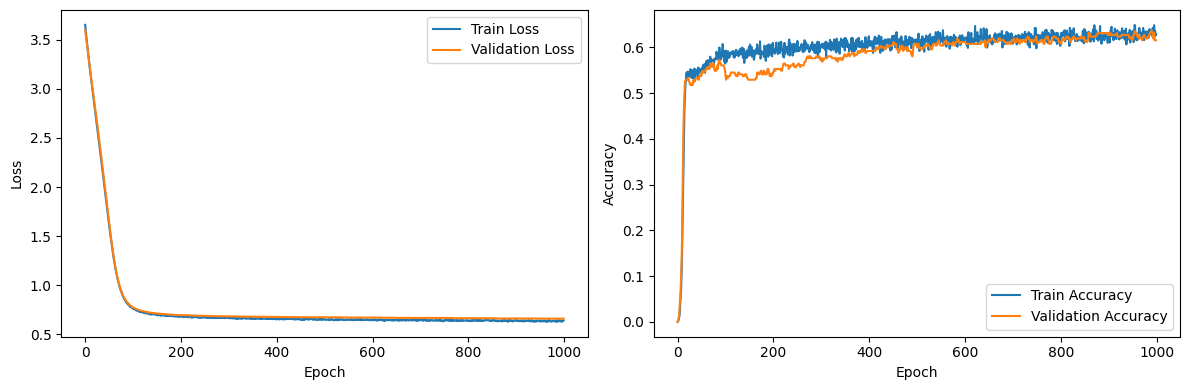


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9566, Val Loss: 2.8948, Train Acc: 0.4846, Val Acc: 0.5085
Epoch: 020, Train Loss: 2.5766, Val Loss: 2.5219, Train Acc: 0.5191, Val Acc: 0.4703
Epoch: 030, Train Loss: 2.1744, Val Loss: 2.1320, Train Acc: 0.5354, Val Acc: 0.5042
Epoch: 040, Train Loss: 1.7577, Val Loss: 1.7305, Train Acc: 0.5508, Val Acc: 0.4915
Epoch: 050, Train Loss: 1.3851, Val Loss: 1.3668, Train Acc: 0.5544, Val Acc: 0.4831
Epoch: 060, Train Loss: 1.1068, Val Loss: 1.0996, Train Acc: 0.5690, Val Acc: 0.5042
Epoch: 070, Train Loss: 0.9380, Val Loss: 0.9394, Train Acc: 0.5681, Val Acc: 0.5085
Epoch: 080, Train Loss: 0.8397, Val Loss: 0.8534, Train Acc: 0.5789, Val Acc: 0.5169
Epoch: 090, Train Loss: 0.7864, Val Loss: 0.8076, Train Acc: 0.5880, Val Acc: 0.5000
Epoch: 100, Train Loss: 0.7583, Val Loss: 0.7816, Train Acc: 0.5762, Val Acc: 0.4958
Epoch: 110, Train Loss: 0.7393, Val Loss: 0.7649, Tr

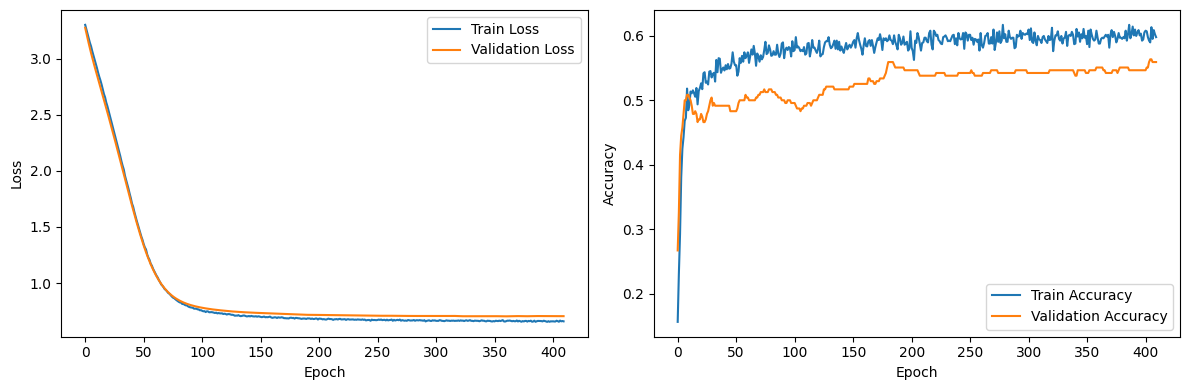


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0682, Val Loss: 2.9835, Train Acc: 0.4970, Val Acc: 0.4954
Epoch: 020, Train Loss: 2.6845, Val Loss: 2.5865, Train Acc: 0.5059, Val Acc: 0.4954
Epoch: 030, Train Loss: 2.2942, Val Loss: 2.1902, Train Acc: 0.5148, Val Acc: 0.4908
Epoch: 040, Train Loss: 1.8755, Val Loss: 1.7873, Train Acc: 0.5177, Val Acc: 0.4908
Epoch: 050, Train Loss: 1.4896, Val Loss: 1.4180, Train Acc: 0.5187, Val Acc: 0.4954
Epoch: 060, Train Loss: 1.1745, Val Loss: 1.1365, Train Acc: 0.5256, Val Acc: 0.5000
Epoch: 070, Train Loss: 0.9711, Val Loss: 0.9604, Train Acc: 0.5522, Val Acc: 0.5459
Epoch: 080, Train Loss: 0.8653, Val Loss: 0.8635, Train Acc: 0.5344, Val Acc: 0.5046
Epoch: 090, Train Loss: 0.8045, Val Loss: 0.8112, Train Acc: 0.5640, Val Acc: 0.5138
Epoch: 100, Train Loss: 0.7656, Val Loss: 0.7807, Train Acc: 0.5492, Val Acc: 0.5138
Epoch: 110, Train Loss: 0.7511, Val Loss: 0.7617, Tr

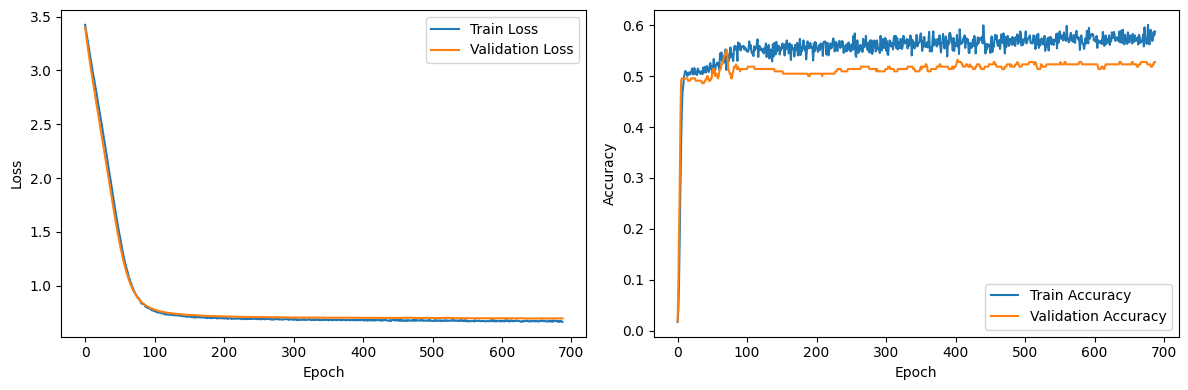


========== Run 6 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2368, Val Loss: 3.1676, Train Acc: 0.2337, Val Acc: 0.3835
Epoch: 020, Train Loss: 2.8812, Val Loss: 2.8140, Train Acc: 0.4907, Val Acc: 0.5226
Epoch: 030, Train Loss: 2.5029, Val Loss: 2.4441, Train Acc: 0.5181, Val Acc: 0.5113
Epoch: 040, Train Loss: 2.0984, Val Loss: 2.0411, Train Acc: 0.5334, Val Acc: 0.5263
Epoch: 050, Train Loss: 1.6754, Val Loss: 1.6310, Train Acc: 0.5423, Val Acc: 0.5338
Epoch: 060, Train Loss: 1.3115, Val Loss: 1.2760, Train Acc: 0.5367, Val Acc: 0.5301
Epoch: 070, Train Loss: 1.0498, Val Loss: 1.0297, Train Acc: 0.5520, Val Acc: 0.5451
Epoch: 080, Train Loss: 0.9048, Val Loss: 0.8905, Train Acc: 0.5584, Val Acc: 0.5639
Epoch: 090, Train Loss: 0.8252, Val Loss: 0.8187, Train Acc: 0.5665, Val Acc: 0.5714
Epoch: 100, Train Loss: 0.7785, Val Loss: 0.7809, Train Acc: 0.5939, Val Acc: 0.5789
Epoch: 110, Train Loss

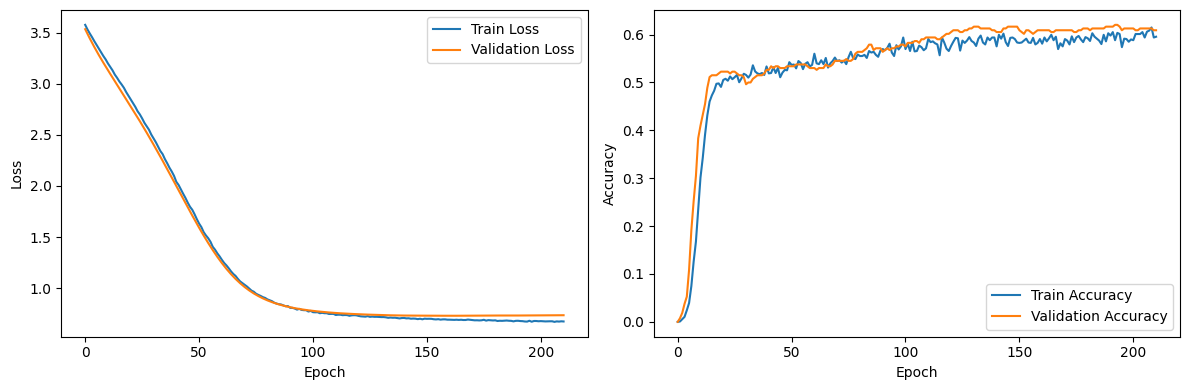


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0608, Val Loss: 3.0621, Train Acc: 0.4992, Val Acc: 0.5020
Epoch: 020, Train Loss: 2.7168, Val Loss: 2.7426, Train Acc: 0.5084, Val Acc: 0.4980
Epoch: 030, Train Loss: 2.3570, Val Loss: 2.3899, Train Acc: 0.5193, Val Acc: 0.5098
Epoch: 040, Train Loss: 1.9785, Val Loss: 1.9973, Train Acc: 0.5218, Val Acc: 0.4980
Epoch: 050, Train Loss: 1.5909, Val Loss: 1.6007, Train Acc: 0.5151, Val Acc: 0.4980
Epoch: 060, Train Loss: 1.2670, Val Loss: 1.2666, Train Acc: 0.5260, Val Acc: 0.5137
Epoch: 070, Train Loss: 1.0332, Val Loss: 1.0400, Train Acc: 0.5411, Val Acc: 0.5176
Epoch: 080, Train Loss: 0.9019, Val Loss: 0.9061, Train Acc: 0.5503, Val Acc: 0.5059
Epoch: 090, Train Loss: 0.8251, Val Loss: 0.8303, Train Acc: 0.5554, Val Acc: 0.4941
Epoch: 100, Train Loss: 0.7767, Val Loss: 0.7866, Train Acc: 0.5696, Val Acc: 0.5608
Epoch: 110, Train Loss: 0.7538, Val Loss: 0.7593, Tr

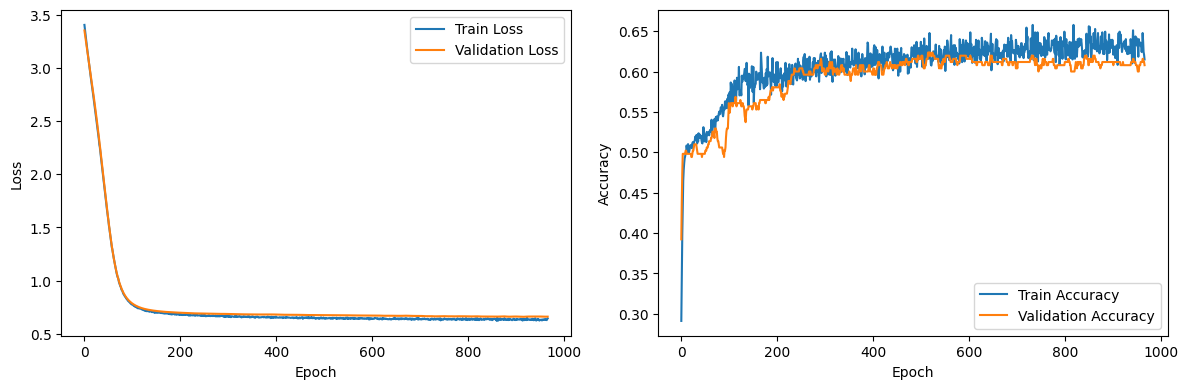


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1223, Val Loss: 3.0474, Train Acc: 0.4120, Val Acc: 0.4788
Epoch: 020, Train Loss: 2.7114, Val Loss: 2.6295, Train Acc: 0.5200, Val Acc: 0.5127
Epoch: 030, Train Loss: 2.2882, Val Loss: 2.2157, Train Acc: 0.5290, Val Acc: 0.5212
Epoch: 040, Train Loss: 1.8451, Val Loss: 1.7925, Train Acc: 0.5463, Val Acc: 0.5085
Epoch: 050, Train Loss: 1.4463, Val Loss: 1.4042, Train Acc: 0.5390, Val Acc: 0.5085
Epoch: 060, Train Loss: 1.1412, Val Loss: 1.1151, Train Acc: 0.5354, Val Acc: 0.5127
Epoch: 070, Train Loss: 0.9427, Val Loss: 0.9418, Train Acc: 0.5508, Val Acc: 0.5085
Epoch: 080, Train Loss: 0.8514, Val Loss: 0.8504, Train Acc: 0.5699, Val Acc: 0.4746
Epoch: 090, Train Loss: 0.7891, Val Loss: 0.8017, Train Acc: 0.5898, Val Acc: 0.5085
Epoch: 100, Train Loss: 0.7567, Val Loss: 0.7759, Train Acc: 0.5635, Val Acc: 0.5212
Epoch: 110, Train Loss: 0.7320, Val Loss: 0.7619, Tr

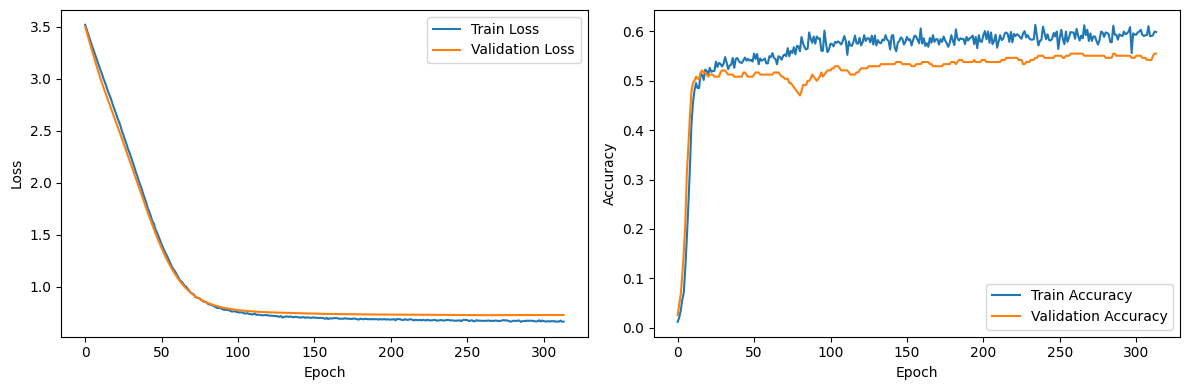


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0581, Val Loss: 3.0079, Train Acc: 0.4626, Val Acc: 0.4862
Epoch: 020, Train Loss: 2.6301, Val Loss: 2.5633, Train Acc: 0.5020, Val Acc: 0.5092
Epoch: 030, Train Loss: 2.1941, Val Loss: 2.1306, Train Acc: 0.5039, Val Acc: 0.4954
Epoch: 040, Train Loss: 1.7615, Val Loss: 1.7168, Train Acc: 0.5148, Val Acc: 0.4771
Epoch: 050, Train Loss: 1.3923, Val Loss: 1.3657, Train Acc: 0.5187, Val Acc: 0.4817
Epoch: 060, Train Loss: 1.1298, Val Loss: 1.1140, Train Acc: 0.5167, Val Acc: 0.4862
Epoch: 070, Train Loss: 0.9603, Val Loss: 0.9568, Train Acc: 0.5246, Val Acc: 0.4862
Epoch: 080, Train Loss: 0.8649, Val Loss: 0.8654, Train Acc: 0.5197, Val Acc: 0.4771
Epoch: 090, Train Loss: 0.8001, Val Loss: 0.8120, Train Acc: 0.5344, Val Acc: 0.4908
Epoch: 100, Train Loss: 0.7702, Val Loss: 0.7796, Train Acc: 0.5285, Val Acc: 0.5046
Epoch: 110, Train Loss: 0.7547, Val Loss: 0.7599, Tr

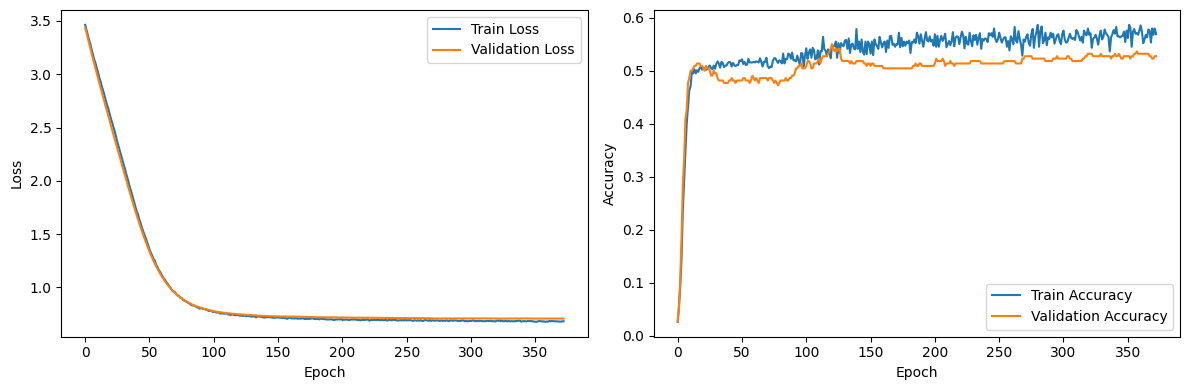


========== Run 7 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1977, Val Loss: 3.1575, Train Acc: 0.3336, Val Acc: 0.3609
Epoch: 020, Train Loss: 2.7712, Val Loss: 2.7082, Train Acc: 0.4899, Val Acc: 0.5000
Epoch: 030, Train Loss: 2.3418, Val Loss: 2.2735, Train Acc: 0.5157, Val Acc: 0.5188
Epoch: 040, Train Loss: 1.8907, Val Loss: 1.8343, Train Acc: 0.5270, Val Acc: 0.5564
Epoch: 050, Train Loss: 1.4885, Val Loss: 1.4333, Train Acc: 0.5471, Val Acc: 0.5677
Epoch: 060, Train Loss: 1.1742, Val Loss: 1.1296, Train Acc: 0.5641, Val Acc: 0.5752
Epoch: 070, Train Loss: 0.9722, Val Loss: 0.9422, Train Acc: 0.5810, Val Acc: 0.5977
Epoch: 080, Train Loss: 0.8566, Val Loss: 0.8419, Train Acc: 0.5834, Val Acc: 0.6165
Epoch: 090, Train Loss: 0.7941, Val Loss: 0.7905, Train Acc: 0.5834, Val Acc: 0.6241
Epoch: 100, Train Loss: 0.7619, Val Loss: 0.7625, Train Acc: 0.5778, Val Acc: 0.6203
Epoch: 110, Train Loss

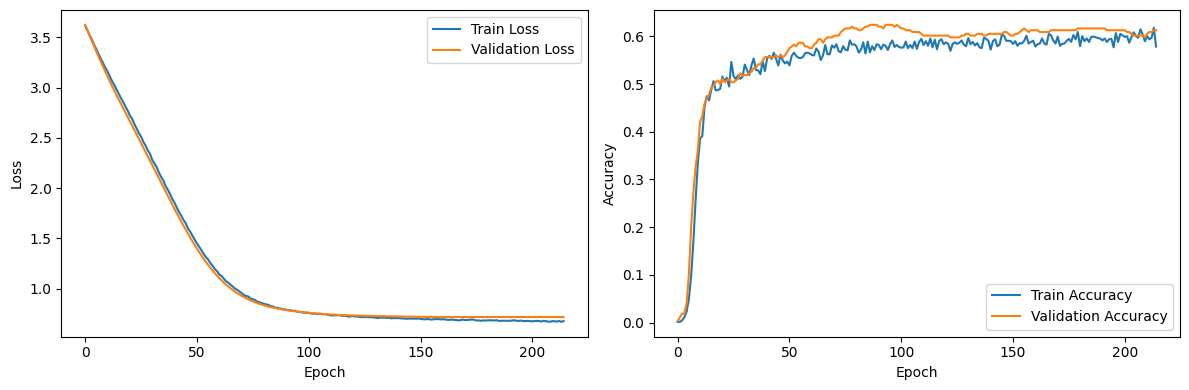


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2267, Val Loss: 3.2311, Train Acc: 0.1628, Val Acc: 0.1882
Epoch: 020, Train Loss: 2.8784, Val Loss: 2.9169, Train Acc: 0.5218, Val Acc: 0.4941
Epoch: 030, Train Loss: 2.5148, Val Loss: 2.5597, Train Acc: 0.5453, Val Acc: 0.4745
Epoch: 040, Train Loss: 2.1145, Val Loss: 2.1508, Train Acc: 0.5520, Val Acc: 0.5059
Epoch: 050, Train Loss: 1.6972, Val Loss: 1.7202, Train Acc: 0.5570, Val Acc: 0.5216
Epoch: 060, Train Loss: 1.3245, Val Loss: 1.3344, Train Acc: 0.5554, Val Acc: 0.5294
Epoch: 070, Train Loss: 1.0557, Val Loss: 1.0614, Train Acc: 0.5671, Val Acc: 0.5333
Epoch: 080, Train Loss: 0.8974, Val Loss: 0.9044, Train Acc: 0.5705, Val Acc: 0.5137
Epoch: 090, Train Loss: 0.8151, Val Loss: 0.8218, Train Acc: 0.5621, Val Acc: 0.5216
Epoch: 100, Train Loss: 0.7672, Val Loss: 0.7777, Train Acc: 0.5965, Val Acc: 0.5412
Epoch: 110, Train Loss: 0.7458, Val Loss: 0.7523, Tr

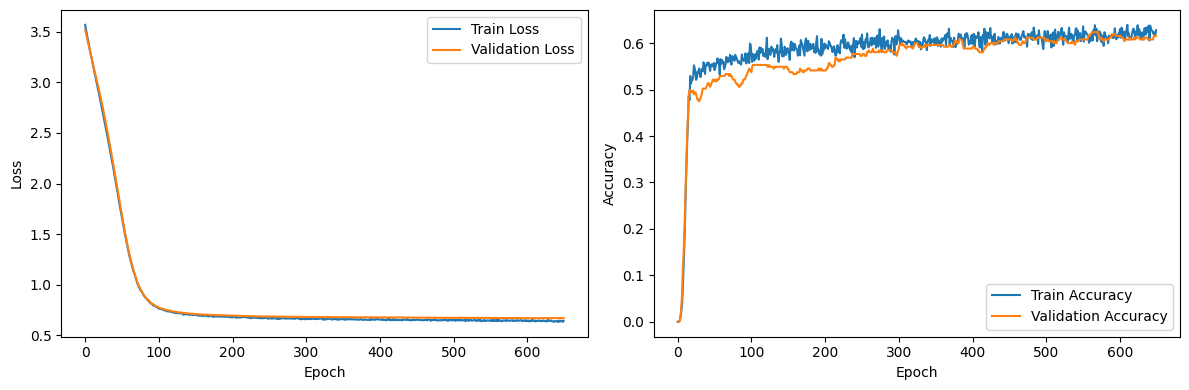


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1484, Val Loss: 3.1159, Train Acc: 0.2269, Val Acc: 0.2669
Epoch: 020, Train Loss: 2.7389, Val Loss: 2.6970, Train Acc: 0.5454, Val Acc: 0.5127
Epoch: 030, Train Loss: 2.3031, Val Loss: 2.2750, Train Acc: 0.5762, Val Acc: 0.5127
Epoch: 040, Train Loss: 1.8761, Val Loss: 1.8457, Train Acc: 0.5799, Val Acc: 0.5127
Epoch: 050, Train Loss: 1.4760, Val Loss: 1.4472, Train Acc: 0.5708, Val Acc: 0.5254
Epoch: 060, Train Loss: 1.1580, Val Loss: 1.1404, Train Acc: 0.5844, Val Acc: 0.5297
Epoch: 070, Train Loss: 0.9627, Val Loss: 0.9515, Train Acc: 0.5799, Val Acc: 0.5297
Epoch: 080, Train Loss: 0.8472, Val Loss: 0.8509, Train Acc: 0.5826, Val Acc: 0.5339
Epoch: 090, Train Loss: 0.7918, Val Loss: 0.7989, Train Acc: 0.5717, Val Acc: 0.5297
Epoch: 100, Train Loss: 0.7621, Val Loss: 0.7710, Train Acc: 0.5717, Val Acc: 0.5339
Epoch: 110, Train Loss: 0.7425, Val Loss: 0.7544, Tr

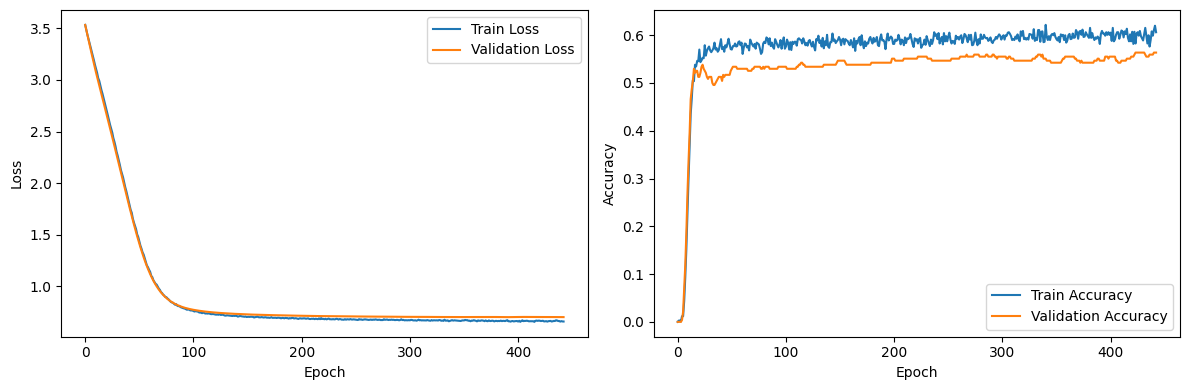


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1580, Val Loss: 3.0490, Train Acc: 0.3022, Val Acc: 0.4587
Epoch: 020, Train Loss: 2.7807, Val Loss: 2.6669, Train Acc: 0.5463, Val Acc: 0.5229
Epoch: 030, Train Loss: 2.3829, Val Loss: 2.2816, Train Acc: 0.5207, Val Acc: 0.5183
Epoch: 040, Train Loss: 1.9716, Val Loss: 1.8830, Train Acc: 0.5531, Val Acc: 0.5092
Epoch: 050, Train Loss: 1.5645, Val Loss: 1.5066, Train Acc: 0.5433, Val Acc: 0.4954
Epoch: 060, Train Loss: 1.2302, Val Loss: 1.2065, Train Acc: 0.5394, Val Acc: 0.4954
Epoch: 070, Train Loss: 1.0139, Val Loss: 1.0097, Train Acc: 0.5492, Val Acc: 0.5000
Epoch: 080, Train Loss: 0.8903, Val Loss: 0.8960, Train Acc: 0.5561, Val Acc: 0.4954
Epoch: 090, Train Loss: 0.8181, Val Loss: 0.8321, Train Acc: 0.5669, Val Acc: 0.4954
Epoch: 100, Train Loss: 0.7781, Val Loss: 0.7950, Train Acc: 0.5551, Val Acc: 0.4954
Epoch: 110, Train Loss: 0.7522, Val Loss: 0.7723, Tr

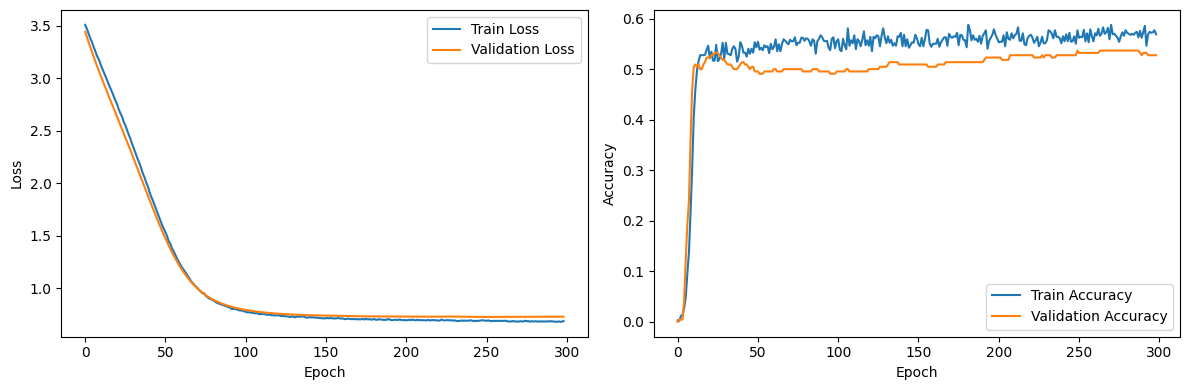


========== Run 8 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1909, Val Loss: 3.1230, Train Acc: 0.2417, Val Acc: 0.3346
Epoch: 020, Train Loss: 2.8297, Val Loss: 2.7448, Train Acc: 0.5302, Val Acc: 0.5414
Epoch: 030, Train Loss: 2.4358, Val Loss: 2.3566, Train Acc: 0.5624, Val Acc: 0.5451
Epoch: 040, Train Loss: 1.9944, Val Loss: 1.9316, Train Acc: 0.5826, Val Acc: 0.5639
Epoch: 050, Train Loss: 1.5812, Val Loss: 1.5067, Train Acc: 0.5681, Val Acc: 0.5602
Epoch: 060, Train Loss: 1.2190, Val Loss: 1.1599, Train Acc: 0.5939, Val Acc: 0.5752
Epoch: 070, Train Loss: 0.9880, Val Loss: 0.9399, Train Acc: 0.6011, Val Acc: 0.5977
Epoch: 080, Train Loss: 0.8596, Val Loss: 0.8243, Train Acc: 0.5971, Val Acc: 0.6128
Epoch: 090, Train Loss: 0.7913, Val Loss: 0.7667, Train Acc: 0.5971, Val Acc: 0.6165
Epoch: 100, Train Loss: 0.7517, Val Loss: 0.7382, Train Acc: 0.5979, Val Acc: 0.6203
Epoch: 110, Train Loss

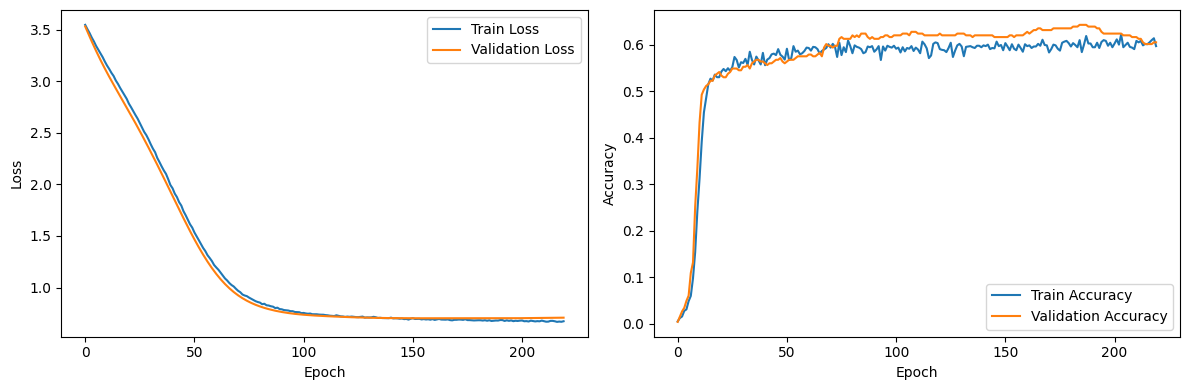


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1145, Val Loss: 3.1165, Train Acc: 0.4421, Val Acc: 0.4706
Epoch: 020, Train Loss: 2.7097, Val Loss: 2.7413, Train Acc: 0.5445, Val Acc: 0.4902
Epoch: 030, Train Loss: 2.3159, Val Loss: 2.3506, Train Acc: 0.5537, Val Acc: 0.5098
Epoch: 040, Train Loss: 1.9148, Val Loss: 1.9337, Train Acc: 0.5537, Val Acc: 0.4941
Epoch: 050, Train Loss: 1.5157, Val Loss: 1.5210, Train Acc: 0.5503, Val Acc: 0.4902
Epoch: 060, Train Loss: 1.1870, Val Loss: 1.1831, Train Acc: 0.5537, Val Acc: 0.5059
Epoch: 070, Train Loss: 0.9669, Val Loss: 0.9678, Train Acc: 0.5529, Val Acc: 0.5098
Epoch: 080, Train Loss: 0.8469, Val Loss: 0.8531, Train Acc: 0.5646, Val Acc: 0.5137
Epoch: 090, Train Loss: 0.7886, Val Loss: 0.7939, Train Acc: 0.5780, Val Acc: 0.5255
Epoch: 100, Train Loss: 0.7541, Val Loss: 0.7613, Train Acc: 0.5705, Val Acc: 0.5176
Epoch: 110, Train Loss: 0.7299, Val Loss: 0.7417, Tr

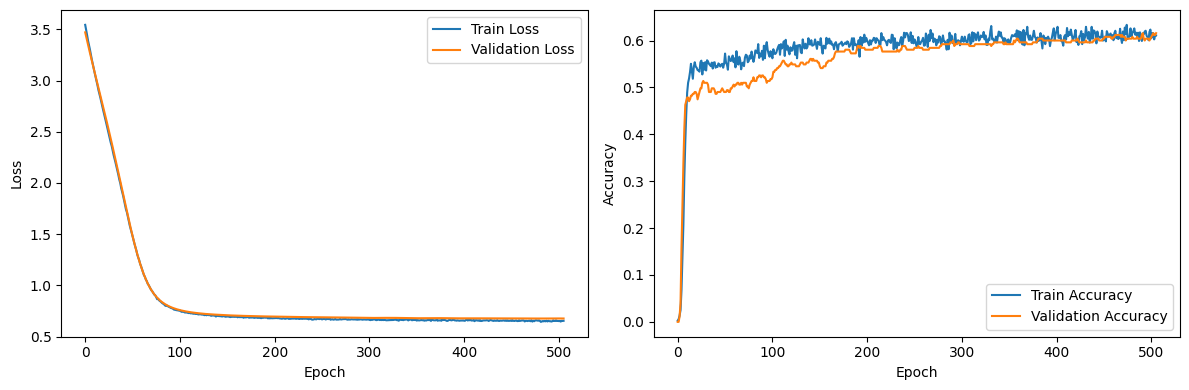


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2027, Val Loss: 3.1545, Train Acc: 0.4310, Val Acc: 0.4746
Epoch: 020, Train Loss: 2.8866, Val Loss: 2.8373, Train Acc: 0.5073, Val Acc: 0.4915
Epoch: 030, Train Loss: 2.5604, Val Loss: 2.5083, Train Acc: 0.4936, Val Acc: 0.5042
Epoch: 040, Train Loss: 2.2003, Val Loss: 2.1520, Train Acc: 0.5027, Val Acc: 0.5212
Epoch: 050, Train Loss: 1.8183, Val Loss: 1.7731, Train Acc: 0.5027, Val Acc: 0.5212
Epoch: 060, Train Loss: 1.4487, Val Loss: 1.4084, Train Acc: 0.5045, Val Acc: 0.5297
Epoch: 070, Train Loss: 1.1463, Val Loss: 1.1198, Train Acc: 0.5100, Val Acc: 0.5381
Epoch: 080, Train Loss: 0.9541, Val Loss: 0.9390, Train Acc: 0.5227, Val Acc: 0.5254
Epoch: 090, Train Loss: 0.8485, Val Loss: 0.8434, Train Acc: 0.5771, Val Acc: 0.5212
Epoch: 100, Train Loss: 0.7873, Val Loss: 0.7954, Train Acc: 0.5926, Val Acc: 0.5381
Epoch: 110, Train Loss: 0.7580, Val Loss: 0.7702, Tr

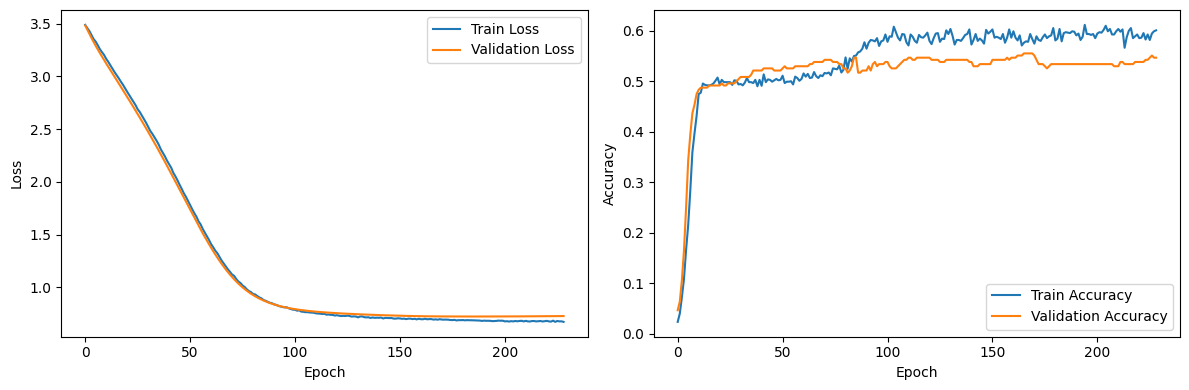


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1014, Val Loss: 3.0331, Train Acc: 0.3878, Val Acc: 0.4037
Epoch: 020, Train Loss: 2.7355, Val Loss: 2.6430, Train Acc: 0.5187, Val Acc: 0.4862
Epoch: 030, Train Loss: 2.3630, Val Loss: 2.2575, Train Acc: 0.5276, Val Acc: 0.4817
Epoch: 040, Train Loss: 1.9724, Val Loss: 1.8719, Train Acc: 0.5207, Val Acc: 0.4817
Epoch: 050, Train Loss: 1.5751, Val Loss: 1.5107, Train Acc: 0.5354, Val Acc: 0.4862
Epoch: 060, Train Loss: 1.2433, Val Loss: 1.2149, Train Acc: 0.5394, Val Acc: 0.4725
Epoch: 070, Train Loss: 1.0191, Val Loss: 1.0150, Train Acc: 0.5394, Val Acc: 0.4817
Epoch: 080, Train Loss: 0.8832, Val Loss: 0.9004, Train Acc: 0.5640, Val Acc: 0.4862
Epoch: 090, Train Loss: 0.8169, Val Loss: 0.8368, Train Acc: 0.5571, Val Acc: 0.4817
Epoch: 100, Train Loss: 0.7763, Val Loss: 0.7988, Train Acc: 0.5600, Val Acc: 0.4817
Epoch: 110, Train Loss: 0.7551, Val Loss: 0.7736, Tr

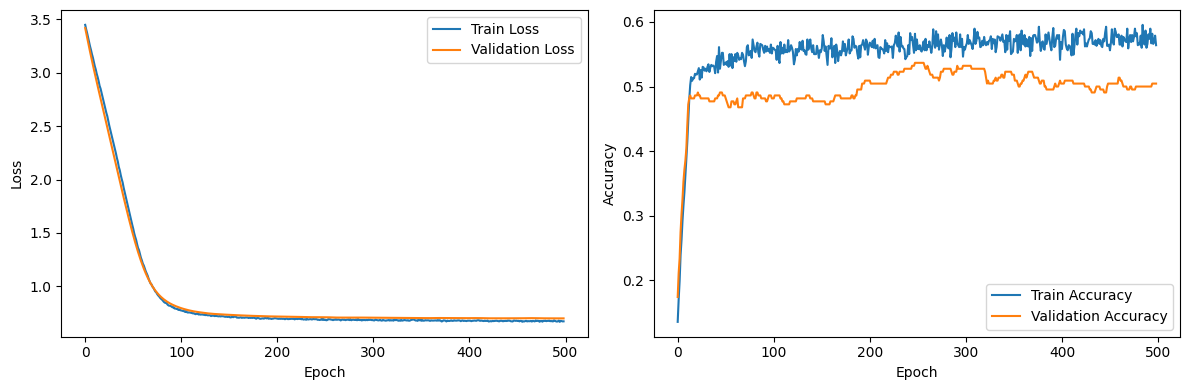


========== Run 9 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1235, Val Loss: 3.0729, Train Acc: 0.5060, Val Acc: 0.5489
Epoch: 020, Train Loss: 2.7623, Val Loss: 2.6949, Train Acc: 0.5528, Val Acc: 0.5602
Epoch: 030, Train Loss: 2.4031, Val Loss: 2.3439, Train Acc: 0.5455, Val Acc: 0.5789
Epoch: 040, Train Loss: 2.0348, Val Loss: 1.9790, Train Acc: 0.5520, Val Acc: 0.5865
Epoch: 050, Train Loss: 1.6637, Val Loss: 1.6131, Train Acc: 0.5504, Val Acc: 0.5827
Epoch: 060, Train Loss: 1.3354, Val Loss: 1.2882, Train Acc: 0.5584, Val Acc: 0.5789
Epoch: 070, Train Loss: 1.0734, Val Loss: 1.0470, Train Acc: 0.5633, Val Acc: 0.5789
Epoch: 080, Train Loss: 0.9118, Val Loss: 0.9024, Train Acc: 0.5592, Val Acc: 0.5827
Epoch: 090, Train Loss: 0.8295, Val Loss: 0.8265, Train Acc: 0.5770, Val Acc: 0.5977
Epoch: 100, Train Loss: 0.7732, Val Loss: 0.7884, Train Acc: 0.5818, Val Acc: 0.6053
Epoch: 110, Train Loss

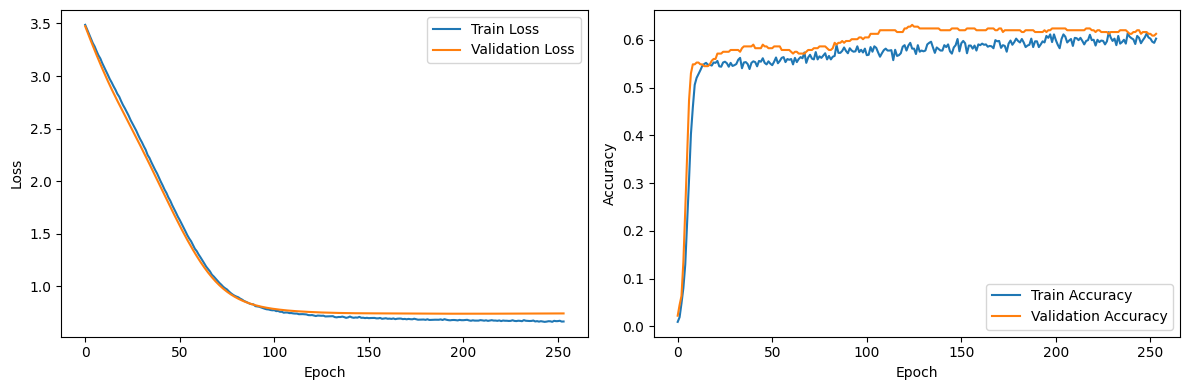


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1000, Val Loss: 3.0813, Train Acc: 0.4815, Val Acc: 0.5020
Epoch: 020, Train Loss: 2.6619, Val Loss: 2.6695, Train Acc: 0.5000, Val Acc: 0.5020
Epoch: 030, Train Loss: 2.2343, Val Loss: 2.2420, Train Acc: 0.5025, Val Acc: 0.5020
Epoch: 040, Train Loss: 1.8051, Val Loss: 1.8113, Train Acc: 0.5050, Val Acc: 0.5020
Epoch: 050, Train Loss: 1.4260, Val Loss: 1.4245, Train Acc: 0.5101, Val Acc: 0.5098
Epoch: 060, Train Loss: 1.1445, Val Loss: 1.1354, Train Acc: 0.5067, Val Acc: 0.5137
Epoch: 070, Train Loss: 0.9599, Val Loss: 0.9535, Train Acc: 0.5067, Val Acc: 0.5137
Epoch: 080, Train Loss: 0.8518, Val Loss: 0.8493, Train Acc: 0.5252, Val Acc: 0.5216
Epoch: 090, Train Loss: 0.7900, Val Loss: 0.7918, Train Acc: 0.5629, Val Acc: 0.5451
Epoch: 100, Train Loss: 0.7579, Val Loss: 0.7599, Train Acc: 0.5696, Val Acc: 0.5569
Epoch: 110, Train Loss: 0.7393, Val Loss: 0.7408, Tr

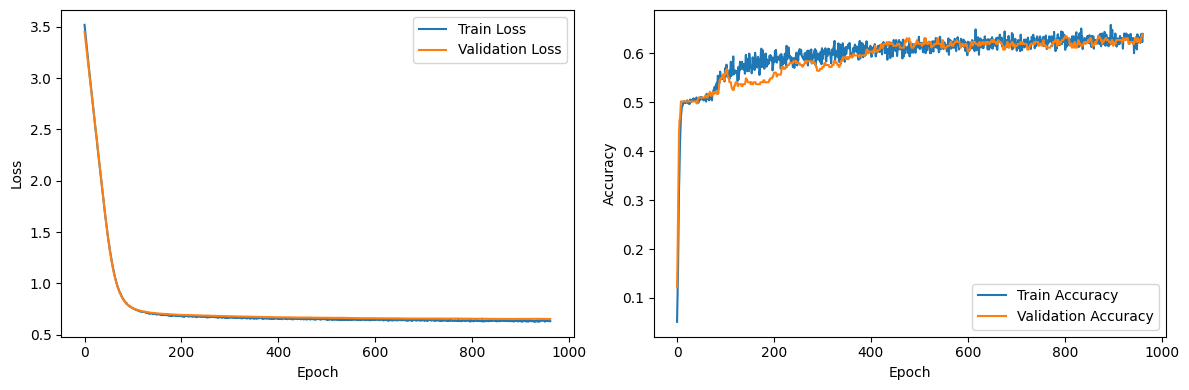


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2171, Val Loss: 3.1889, Train Acc: 0.2995, Val Acc: 0.3051
Epoch: 020, Train Loss: 2.8217, Val Loss: 2.7908, Train Acc: 0.5590, Val Acc: 0.4831
Epoch: 030, Train Loss: 2.4128, Val Loss: 2.3826, Train Acc: 0.5635, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.9740, Val Loss: 1.9561, Train Acc: 0.5626, Val Acc: 0.4915
Epoch: 050, Train Loss: 1.5548, Val Loss: 1.5428, Train Acc: 0.5653, Val Acc: 0.4873
Epoch: 060, Train Loss: 1.2060, Val Loss: 1.2060, Train Acc: 0.5708, Val Acc: 0.5000
Epoch: 070, Train Loss: 0.9867, Val Loss: 0.9896, Train Acc: 0.5771, Val Acc: 0.5127
Epoch: 080, Train Loss: 0.8613, Val Loss: 0.8723, Train Acc: 0.5753, Val Acc: 0.5297
Epoch: 090, Train Loss: 0.8002, Val Loss: 0.8110, Train Acc: 0.5662, Val Acc: 0.5339
Epoch: 100, Train Loss: 0.7641, Val Loss: 0.7773, Train Acc: 0.5835, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.7427, Val Loss: 0.7569, Tr

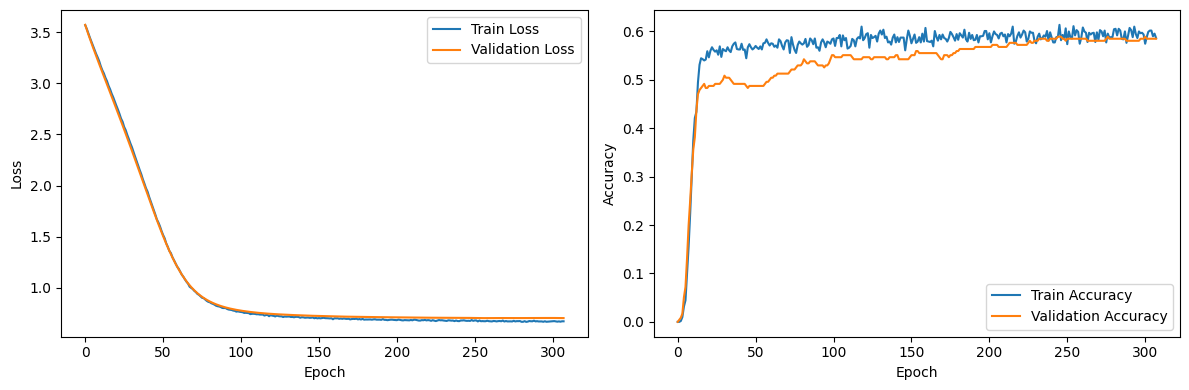


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1340, Val Loss: 3.0451, Train Acc: 0.4400, Val Acc: 0.4771
Epoch: 020, Train Loss: 2.7407, Val Loss: 2.6446, Train Acc: 0.5226, Val Acc: 0.5229
Epoch: 030, Train Loss: 2.3496, Val Loss: 2.2615, Train Acc: 0.5433, Val Acc: 0.5275
Epoch: 040, Train Loss: 1.9465, Val Loss: 1.8699, Train Acc: 0.5453, Val Acc: 0.5275
Epoch: 050, Train Loss: 1.5501, Val Loss: 1.4947, Train Acc: 0.5453, Val Acc: 0.5229
Epoch: 060, Train Loss: 1.2295, Val Loss: 1.1882, Train Acc: 0.5581, Val Acc: 0.5092
Epoch: 070, Train Loss: 1.0018, Val Loss: 0.9856, Train Acc: 0.5453, Val Acc: 0.5092
Epoch: 080, Train Loss: 0.8747, Val Loss: 0.8729, Train Acc: 0.5502, Val Acc: 0.5092
Epoch: 090, Train Loss: 0.8166, Val Loss: 0.8132, Train Acc: 0.5354, Val Acc: 0.5046
Epoch: 100, Train Loss: 0.7740, Val Loss: 0.7798, Train Acc: 0.5531, Val Acc: 0.5183
Epoch: 110, Train Loss: 0.7476, Val Loss: 0.7585, Tr

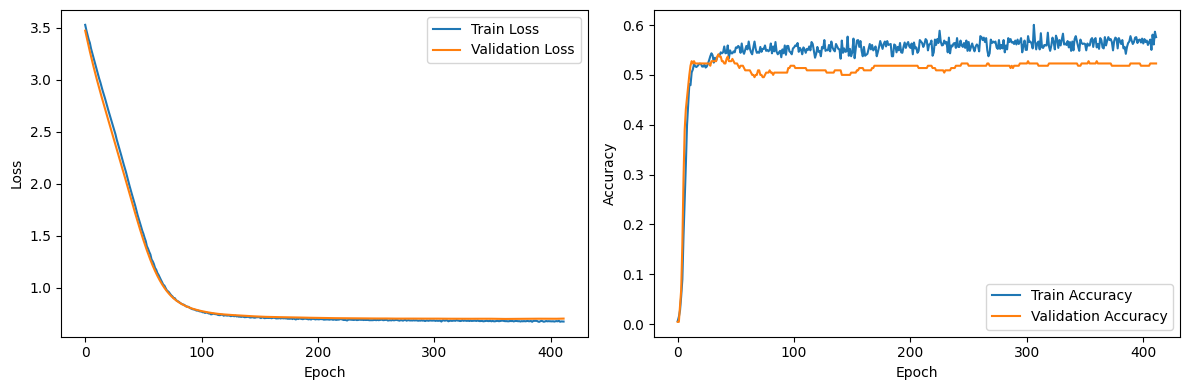


========== Run 10 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0678, Val Loss: 3.0180, Train Acc: 0.5020, Val Acc: 0.5038
Epoch: 020, Train Loss: 2.6494, Val Loss: 2.6025, Train Acc: 0.5222, Val Acc: 0.5075
Epoch: 030, Train Loss: 2.2248, Val Loss: 2.1874, Train Acc: 0.5560, Val Acc: 0.5301
Epoch: 040, Train Loss: 1.7928, Val Loss: 1.7616, Train Acc: 0.5600, Val Acc: 0.5827
Epoch: 050, Train Loss: 1.4042, Val Loss: 1.3704, Train Acc: 0.5874, Val Acc: 0.5865
Epoch: 060, Train Loss: 1.1069, Val Loss: 1.0821, Train Acc: 0.5890, Val Acc: 0.6053
Epoch: 070, Train Loss: 0.9315, Val Loss: 0.9130, Train Acc: 0.5705, Val Acc: 0.5902
Epoch: 080, Train Loss: 0.8347, Val Loss: 0.8263, Train Acc: 0.5778, Val Acc: 0.5789
Epoch: 090, Train Loss: 0.7801, Val Loss: 0.7830, Train Acc: 0.5858, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.7558, Val Loss: 0.7602, Train Acc: 0.5794, Val Acc: 0.5827
Epoch: 110, Train Los

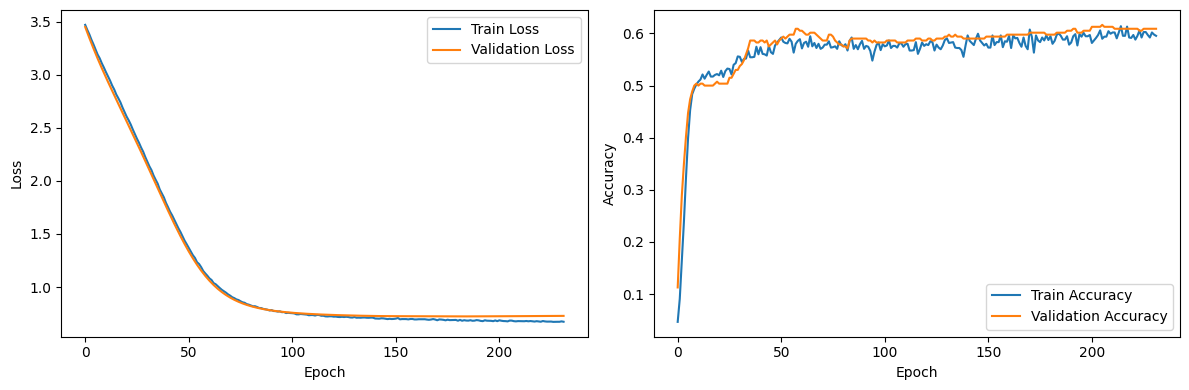


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0659, Val Loss: 3.0690, Train Acc: 0.4681, Val Acc: 0.5059
Epoch: 020, Train Loss: 2.6637, Val Loss: 2.6904, Train Acc: 0.5067, Val Acc: 0.5098
Epoch: 030, Train Loss: 2.2603, Val Loss: 2.2850, Train Acc: 0.5109, Val Acc: 0.5137
Epoch: 040, Train Loss: 1.8452, Val Loss: 1.8589, Train Acc: 0.5227, Val Acc: 0.5059
Epoch: 050, Train Loss: 1.4598, Val Loss: 1.4580, Train Acc: 0.5185, Val Acc: 0.5020
Epoch: 060, Train Loss: 1.1594, Val Loss: 1.1470, Train Acc: 0.5252, Val Acc: 0.5098
Epoch: 070, Train Loss: 0.9586, Val Loss: 0.9523, Train Acc: 0.5336, Val Acc: 0.5137
Epoch: 080, Train Loss: 0.8469, Val Loss: 0.8462, Train Acc: 0.5503, Val Acc: 0.5176
Epoch: 090, Train Loss: 0.7912, Val Loss: 0.7904, Train Acc: 0.5780, Val Acc: 0.5686
Epoch: 100, Train Loss: 0.7584, Val Loss: 0.7596, Train Acc: 0.5864, Val Acc: 0.5647
Epoch: 110, Train Loss: 0.7440, Val Loss: 0.7416, Tr

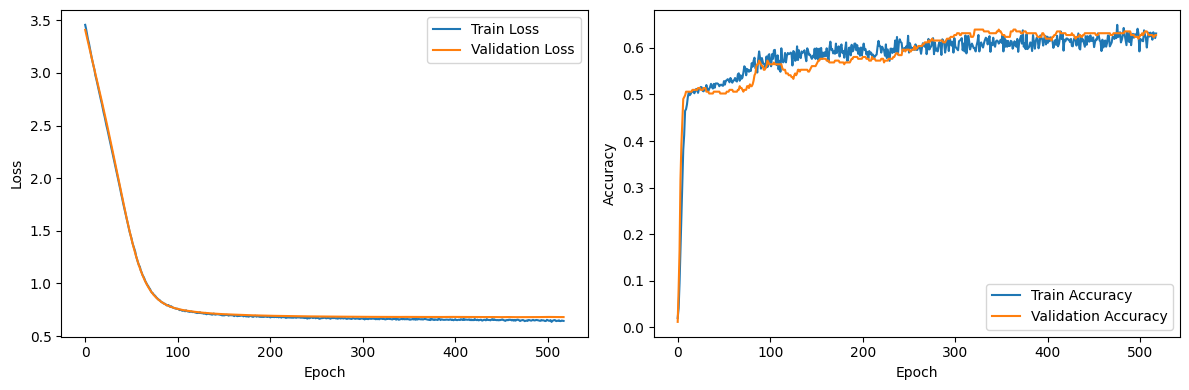


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1109, Val Loss: 3.0717, Train Acc: 0.4601, Val Acc: 0.4110
Epoch: 020, Train Loss: 2.6873, Val Loss: 2.6278, Train Acc: 0.5635, Val Acc: 0.4915
Epoch: 030, Train Loss: 2.2509, Val Loss: 2.2004, Train Acc: 0.5617, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.8070, Val Loss: 1.7726, Train Acc: 0.5699, Val Acc: 0.4958
Epoch: 050, Train Loss: 1.4143, Val Loss: 1.3852, Train Acc: 0.5690, Val Acc: 0.4958
Epoch: 060, Train Loss: 1.1129, Val Loss: 1.0984, Train Acc: 0.5799, Val Acc: 0.5085
Epoch: 070, Train Loss: 0.9345, Val Loss: 0.9288, Train Acc: 0.5789, Val Acc: 0.5000
Epoch: 080, Train Loss: 0.8361, Val Loss: 0.8393, Train Acc: 0.5662, Val Acc: 0.5042
Epoch: 090, Train Loss: 0.7806, Val Loss: 0.7915, Train Acc: 0.5780, Val Acc: 0.5212
Epoch: 100, Train Loss: 0.7506, Val Loss: 0.7643, Train Acc: 0.5835, Val Acc: 0.5212
Epoch: 110, Train Loss: 0.7348, Val Loss: 0.7478, Tr

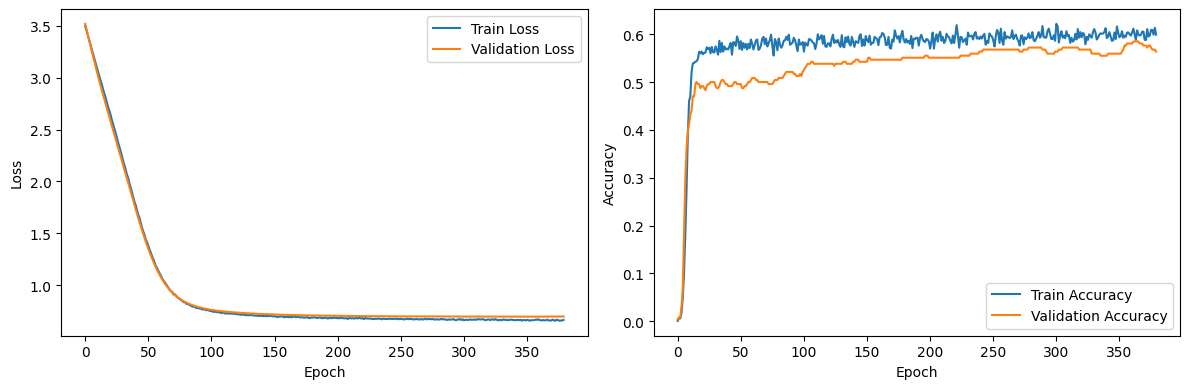


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9534, Val Loss: 2.8396, Train Acc: 0.4892, Val Acc: 0.5138
Epoch: 020, Train Loss: 2.5353, Val Loss: 2.4207, Train Acc: 0.5089, Val Acc: 0.5138
Epoch: 030, Train Loss: 2.1091, Val Loss: 2.0066, Train Acc: 0.5089, Val Acc: 0.5138
Epoch: 040, Train Loss: 1.6896, Val Loss: 1.6087, Train Acc: 0.5108, Val Acc: 0.4954
Epoch: 050, Train Loss: 1.3198, Val Loss: 1.2760, Train Acc: 0.5285, Val Acc: 0.5092
Epoch: 060, Train Loss: 1.0644, Val Loss: 1.0488, Train Acc: 0.5089, Val Acc: 0.5092
Epoch: 070, Train Loss: 0.9172, Val Loss: 0.9167, Train Acc: 0.5197, Val Acc: 0.5000
Epoch: 080, Train Loss: 0.8385, Val Loss: 0.8443, Train Acc: 0.5266, Val Acc: 0.5046
Epoch: 090, Train Loss: 0.7933, Val Loss: 0.8031, Train Acc: 0.5177, Val Acc: 0.4862
Epoch: 100, Train Loss: 0.7671, Val Loss: 0.7770, Train Acc: 0.5246, Val Acc: 0.4862
Epoch: 110, Train Loss: 0.7432, Val Loss: 0.7585, Tr

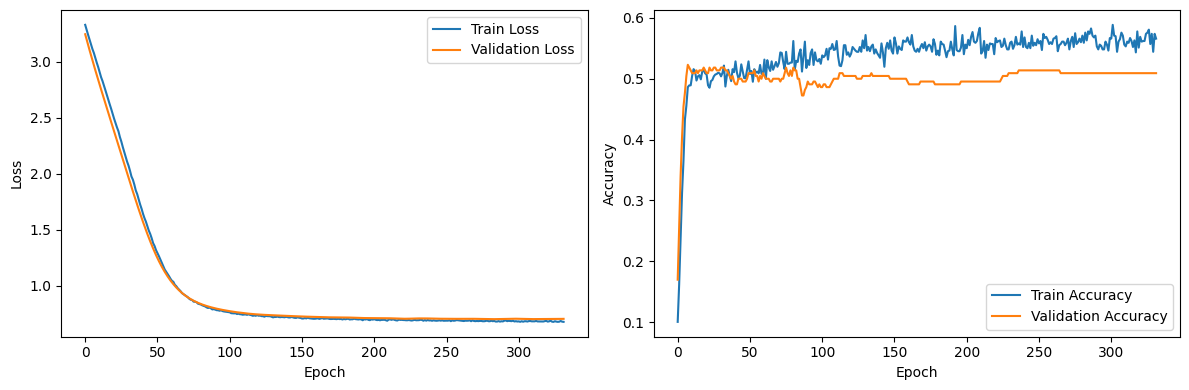


========== Run 11 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1341, Val Loss: 3.0311, Train Acc: 0.3360, Val Acc: 0.4361
Epoch: 020, Train Loss: 2.7824, Val Loss: 2.6816, Train Acc: 0.5399, Val Acc: 0.5564
Epoch: 030, Train Loss: 2.4219, Val Loss: 2.3304, Train Acc: 0.5584, Val Acc: 0.5714
Epoch: 040, Train Loss: 2.0308, Val Loss: 1.9504, Train Acc: 0.5657, Val Acc: 0.5940
Epoch: 050, Train Loss: 1.6391, Val Loss: 1.5622, Train Acc: 0.5608, Val Acc: 0.6203
Epoch: 060, Train Loss: 1.2891, Val Loss: 1.2240, Train Acc: 0.5810, Val Acc: 0.6429
Epoch: 070, Train Loss: 1.0418, Val Loss: 0.9892, Train Acc: 0.5810, Val Acc: 0.6353
Epoch: 080, Train Loss: 0.8905, Val Loss: 0.8560, Train Acc: 0.5866, Val Acc: 0.6203
Epoch: 090, Train Loss: 0.8123, Val Loss: 0.7872, Train Acc: 0.5842, Val Acc: 0.6128
Epoch: 100, Train Loss: 0.7641, Val Loss: 0.7519, Train Acc: 0.5882, Val Acc: 0.6203
Epoch: 110, Train Los

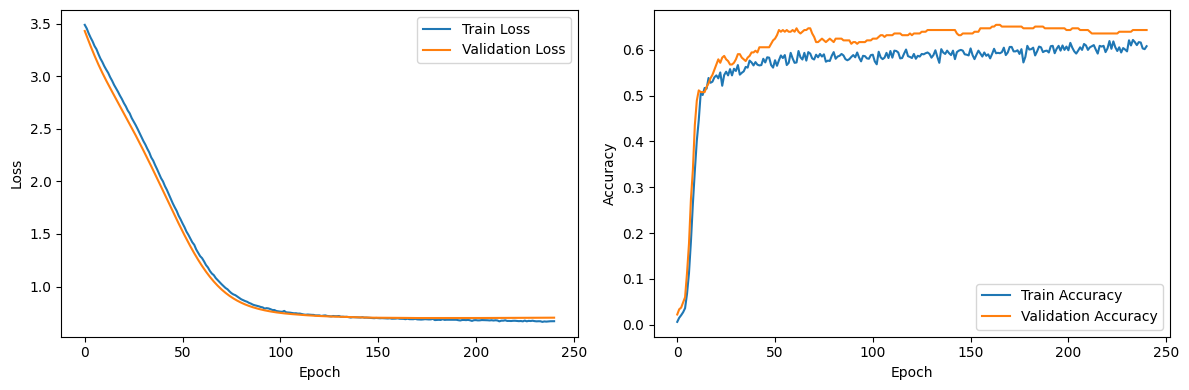


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1469, Val Loss: 3.1375, Train Acc: 0.4153, Val Acc: 0.4824
Epoch: 020, Train Loss: 2.7272, Val Loss: 2.7616, Train Acc: 0.5042, Val Acc: 0.5098
Epoch: 030, Train Loss: 2.3216, Val Loss: 2.3647, Train Acc: 0.5151, Val Acc: 0.5098
Epoch: 040, Train Loss: 1.9112, Val Loss: 1.9445, Train Acc: 0.4983, Val Acc: 0.5137
Epoch: 050, Train Loss: 1.5163, Val Loss: 1.5356, Train Acc: 0.5218, Val Acc: 0.5216
Epoch: 060, Train Loss: 1.1941, Val Loss: 1.2015, Train Acc: 0.5277, Val Acc: 0.5294
Epoch: 070, Train Loss: 0.9823, Val Loss: 0.9843, Train Acc: 0.5277, Val Acc: 0.5176
Epoch: 080, Train Loss: 0.8620, Val Loss: 0.8655, Train Acc: 0.5319, Val Acc: 0.4941
Epoch: 090, Train Loss: 0.8020, Val Loss: 0.8034, Train Acc: 0.5419, Val Acc: 0.4824
Epoch: 100, Train Loss: 0.7580, Val Loss: 0.7692, Train Acc: 0.5587, Val Acc: 0.4902
Epoch: 110, Train Loss: 0.7348, Val Loss: 0.7487, Tr

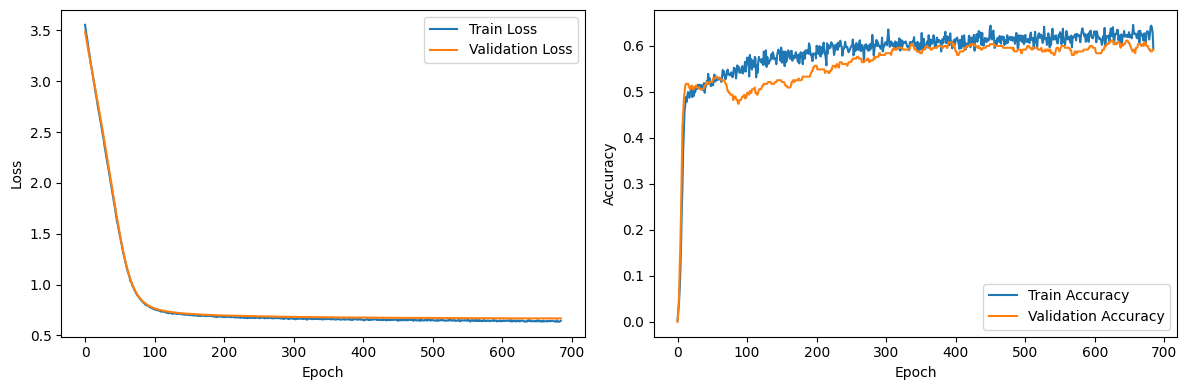


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2118, Val Loss: 3.1395, Train Acc: 0.4510, Val Acc: 0.4915
Epoch: 020, Train Loss: 2.8911, Val Loss: 2.8220, Train Acc: 0.5254, Val Acc: 0.4746
Epoch: 030, Train Loss: 2.5381, Val Loss: 2.4846, Train Acc: 0.5408, Val Acc: 0.4746
Epoch: 040, Train Loss: 2.1464, Val Loss: 2.1098, Train Acc: 0.5608, Val Acc: 0.4873
Epoch: 050, Train Loss: 1.7354, Val Loss: 1.7140, Train Acc: 0.5662, Val Acc: 0.4958
Epoch: 060, Train Loss: 1.3668, Val Loss: 1.3501, Train Acc: 0.5626, Val Acc: 0.5085
Epoch: 070, Train Loss: 1.0778, Val Loss: 1.0811, Train Acc: 0.5735, Val Acc: 0.5042
Epoch: 080, Train Loss: 0.9120, Val Loss: 0.9221, Train Acc: 0.5662, Val Acc: 0.4958
Epoch: 090, Train Loss: 0.8213, Val Loss: 0.8377, Train Acc: 0.5717, Val Acc: 0.4958
Epoch: 100, Train Loss: 0.7711, Val Loss: 0.7913, Train Acc: 0.5826, Val Acc: 0.5085
Epoch: 110, Train Loss: 0.7454, Val Loss: 0.7642, Tr

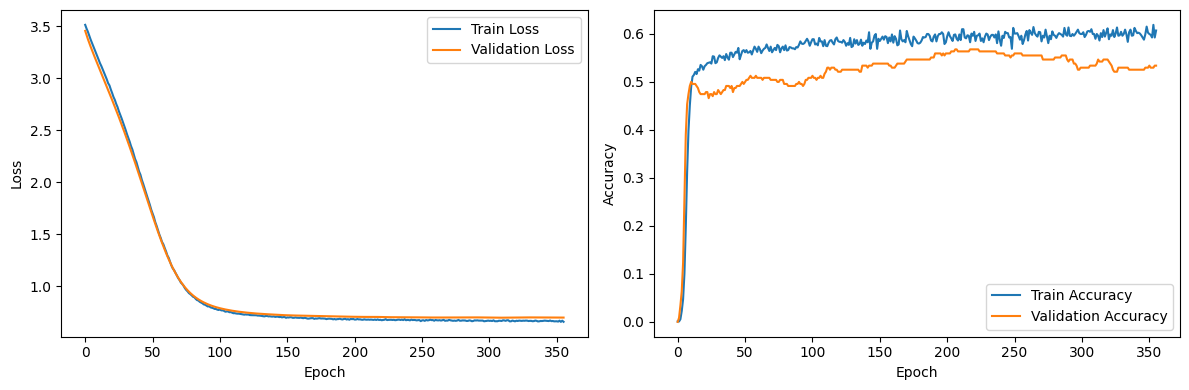


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0728, Val Loss: 3.0036, Train Acc: 0.4862, Val Acc: 0.5229
Epoch: 020, Train Loss: 2.6777, Val Loss: 2.5823, Train Acc: 0.5325, Val Acc: 0.5229
Epoch: 030, Train Loss: 2.2799, Val Loss: 2.1893, Train Acc: 0.5207, Val Acc: 0.5459
Epoch: 040, Train Loss: 1.8758, Val Loss: 1.8008, Train Acc: 0.5344, Val Acc: 0.5367
Epoch: 050, Train Loss: 1.4889, Val Loss: 1.4434, Train Acc: 0.5256, Val Acc: 0.5183
Epoch: 060, Train Loss: 1.1909, Val Loss: 1.1635, Train Acc: 0.5315, Val Acc: 0.4908
Epoch: 070, Train Loss: 0.9849, Val Loss: 0.9819, Train Acc: 0.5423, Val Acc: 0.4771
Epoch: 080, Train Loss: 0.8708, Val Loss: 0.8759, Train Acc: 0.5640, Val Acc: 0.4771
Epoch: 090, Train Loss: 0.8115, Val Loss: 0.8163, Train Acc: 0.5276, Val Acc: 0.4954
Epoch: 100, Train Loss: 0.7756, Val Loss: 0.7818, Train Acc: 0.5522, Val Acc: 0.4908
Epoch: 110, Train Loss: 0.7492, Val Loss: 0.7607, Tr

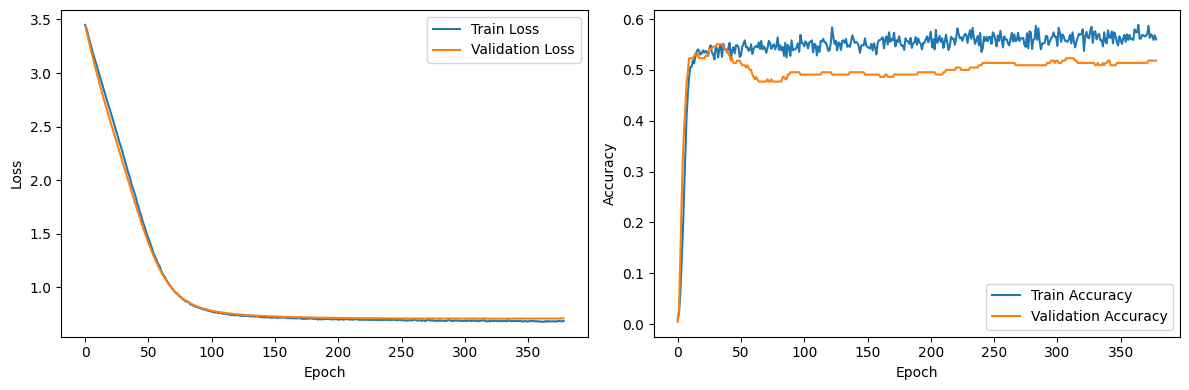


========== Run 12 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9706, Val Loss: 2.8554, Train Acc: 0.5181, Val Acc: 0.6090
Epoch: 020, Train Loss: 2.5474, Val Loss: 2.4311, Train Acc: 0.5512, Val Acc: 0.6241
Epoch: 030, Train Loss: 2.0983, Val Loss: 1.9984, Train Acc: 0.5834, Val Acc: 0.6165
Epoch: 040, Train Loss: 1.6665, Val Loss: 1.5702, Train Acc: 0.5600, Val Acc: 0.6015
Epoch: 050, Train Loss: 1.2881, Val Loss: 1.2115, Train Acc: 0.5681, Val Acc: 0.5902
Epoch: 060, Train Loss: 1.0352, Val Loss: 0.9757, Train Acc: 0.5818, Val Acc: 0.6053
Epoch: 070, Train Loss: 0.8941, Val Loss: 0.8491, Train Acc: 0.5689, Val Acc: 0.6015
Epoch: 080, Train Loss: 0.8156, Val Loss: 0.7865, Train Acc: 0.5657, Val Acc: 0.5902
Epoch: 090, Train Loss: 0.7734, Val Loss: 0.7545, Train Acc: 0.5737, Val Acc: 0.5865
Epoch: 100, Train Loss: 0.7495, Val Loss: 0.7359, Train Acc: 0.5729, Val Acc: 0.5789
Epoch: 110, Train Los

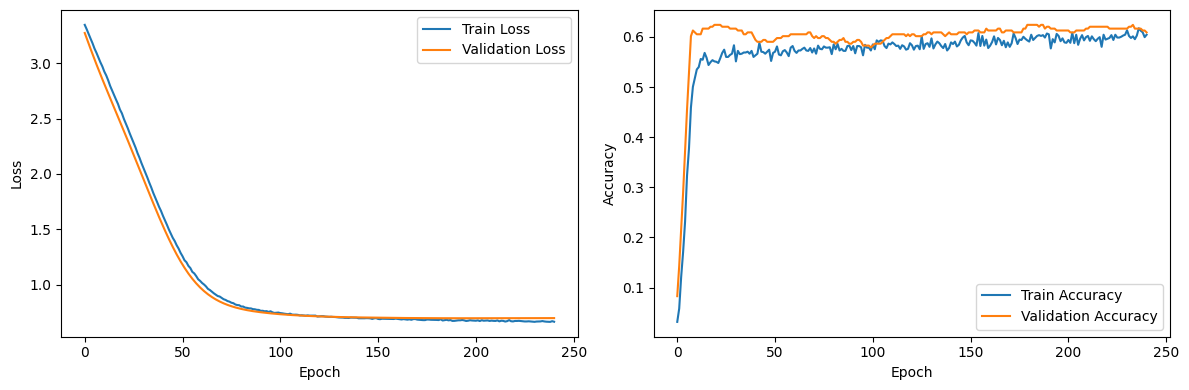


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1742, Val Loss: 3.1780, Train Acc: 0.2299, Val Acc: 0.3373
Epoch: 020, Train Loss: 2.7973, Val Loss: 2.8236, Train Acc: 0.5168, Val Acc: 0.4941
Epoch: 030, Train Loss: 2.4058, Val Loss: 2.4405, Train Acc: 0.5260, Val Acc: 0.4824
Epoch: 040, Train Loss: 2.0076, Val Loss: 2.0225, Train Acc: 0.5646, Val Acc: 0.4667
Epoch: 050, Train Loss: 1.5942, Val Loss: 1.6049, Train Acc: 0.5688, Val Acc: 0.4902
Epoch: 060, Train Loss: 1.2555, Val Loss: 1.2528, Train Acc: 0.5302, Val Acc: 0.4706
Epoch: 070, Train Loss: 1.0073, Val Loss: 1.0156, Train Acc: 0.5310, Val Acc: 0.4863
Epoch: 080, Train Loss: 0.8812, Val Loss: 0.8813, Train Acc: 0.5411, Val Acc: 0.5176
Epoch: 090, Train Loss: 0.8001, Val Loss: 0.8088, Train Acc: 0.5545, Val Acc: 0.5176
Epoch: 100, Train Loss: 0.7629, Val Loss: 0.7690, Train Acc: 0.5889, Val Acc: 0.5216
Epoch: 110, Train Loss: 0.7336, Val Loss: 0.7457, Tr

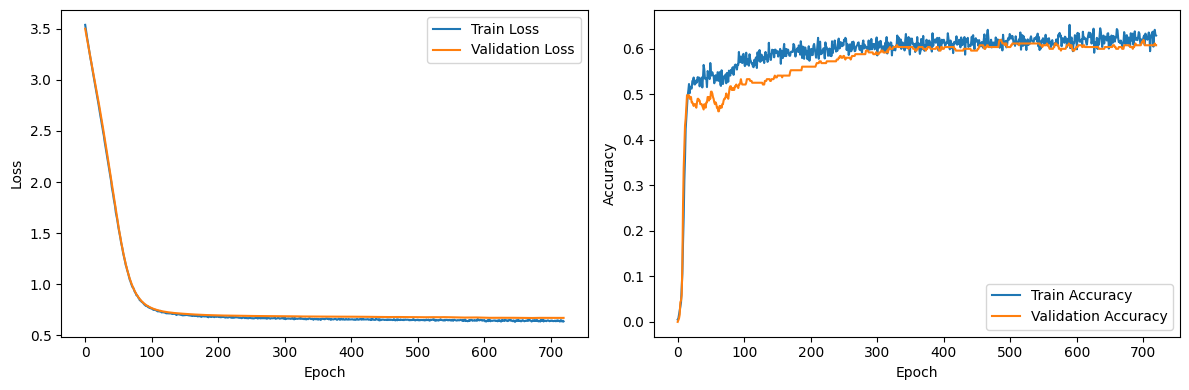


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1672, Val Loss: 3.1437, Train Acc: 0.3403, Val Acc: 0.3559
Epoch: 020, Train Loss: 2.8141, Val Loss: 2.7765, Train Acc: 0.5445, Val Acc: 0.5085
Epoch: 030, Train Loss: 2.4332, Val Loss: 2.4068, Train Acc: 0.5862, Val Acc: 0.5254
Epoch: 040, Train Loss: 2.0288, Val Loss: 2.0147, Train Acc: 0.5708, Val Acc: 0.5127
Epoch: 050, Train Loss: 1.6303, Val Loss: 1.6277, Train Acc: 0.5935, Val Acc: 0.5085
Epoch: 060, Train Loss: 1.2953, Val Loss: 1.2979, Train Acc: 0.5844, Val Acc: 0.5127
Epoch: 070, Train Loss: 1.0539, Val Loss: 1.0649, Train Acc: 0.5699, Val Acc: 0.5127
Epoch: 080, Train Loss: 0.9067, Val Loss: 0.9257, Train Acc: 0.5844, Val Acc: 0.5127
Epoch: 090, Train Loss: 0.8280, Val Loss: 0.8482, Train Acc: 0.5780, Val Acc: 0.5127
Epoch: 100, Train Loss: 0.7804, Val Loss: 0.8046, Train Acc: 0.5780, Val Acc: 0.5127
Epoch: 110, Train Loss: 0.7597, Val Loss: 0.7778, Tr

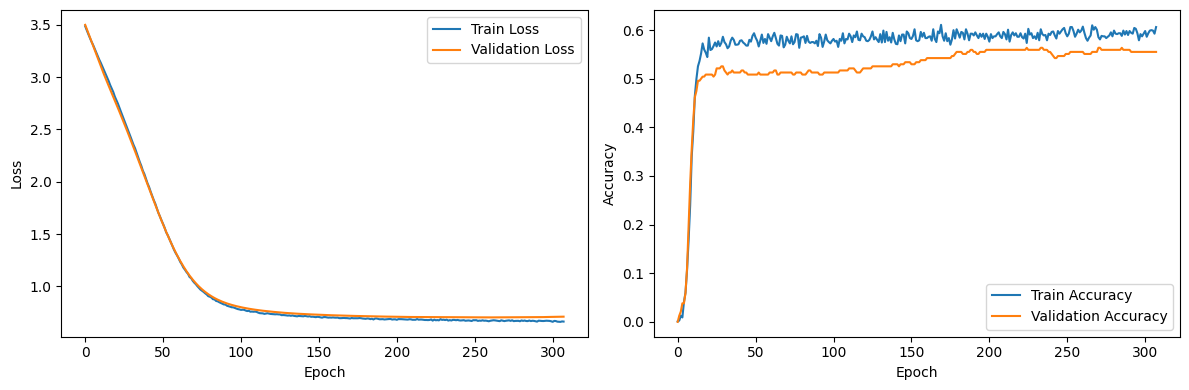


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1723, Val Loss: 3.0403, Train Acc: 0.3081, Val Acc: 0.4312
Epoch: 020, Train Loss: 2.7783, Val Loss: 2.6416, Train Acc: 0.4911, Val Acc: 0.5092
Epoch: 030, Train Loss: 2.3639, Val Loss: 2.2356, Train Acc: 0.4862, Val Acc: 0.5183
Epoch: 040, Train Loss: 1.9339, Val Loss: 1.8222, Train Acc: 0.4951, Val Acc: 0.5092
Epoch: 050, Train Loss: 1.5256, Val Loss: 1.4421, Train Acc: 0.5000, Val Acc: 0.5092
Epoch: 060, Train Loss: 1.2029, Val Loss: 1.1511, Train Acc: 0.4764, Val Acc: 0.5138
Epoch: 070, Train Loss: 0.9914, Val Loss: 0.9690, Train Acc: 0.4980, Val Acc: 0.5138
Epoch: 080, Train Loss: 0.8756, Val Loss: 0.8709, Train Acc: 0.5315, Val Acc: 0.4862
Epoch: 090, Train Loss: 0.8132, Val Loss: 0.8186, Train Acc: 0.5295, Val Acc: 0.4541
Epoch: 100, Train Loss: 0.7757, Val Loss: 0.7872, Train Acc: 0.5512, Val Acc: 0.4771
Epoch: 110, Train Loss: 0.7554, Val Loss: 0.7667, Tr

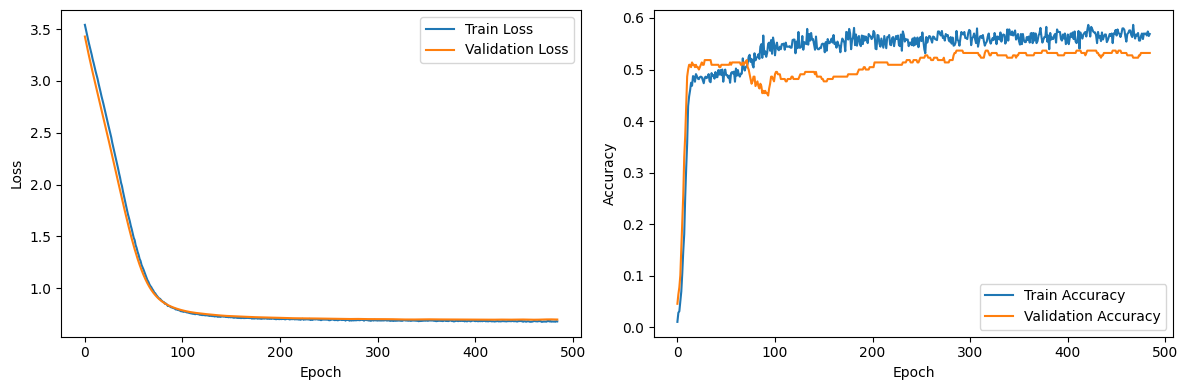


========== Run 13 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1542, Val Loss: 3.0814, Train Acc: 0.4182, Val Acc: 0.5376
Epoch: 020, Train Loss: 2.7816, Val Loss: 2.6886, Train Acc: 0.5189, Val Acc: 0.5489
Epoch: 030, Train Loss: 2.3852, Val Loss: 2.3010, Train Acc: 0.5544, Val Acc: 0.5564
Epoch: 040, Train Loss: 1.9737, Val Loss: 1.8942, Train Acc: 0.5230, Val Acc: 0.5752
Epoch: 050, Train Loss: 1.5698, Val Loss: 1.5026, Train Acc: 0.5576, Val Acc: 0.5865
Epoch: 060, Train Loss: 1.2501, Val Loss: 1.1890, Train Acc: 0.5624, Val Acc: 0.6053
Epoch: 070, Train Loss: 1.0159, Val Loss: 0.9875, Train Acc: 0.5753, Val Acc: 0.6165
Epoch: 080, Train Loss: 0.8933, Val Loss: 0.8780, Train Acc: 0.5608, Val Acc: 0.6128
Epoch: 090, Train Loss: 0.8195, Val Loss: 0.8221, Train Acc: 0.5761, Val Acc: 0.6015
Epoch: 100, Train Loss: 0.7694, Val Loss: 0.7932, Train Acc: 0.5915, Val Acc: 0.6015
Epoch: 110, Train Los

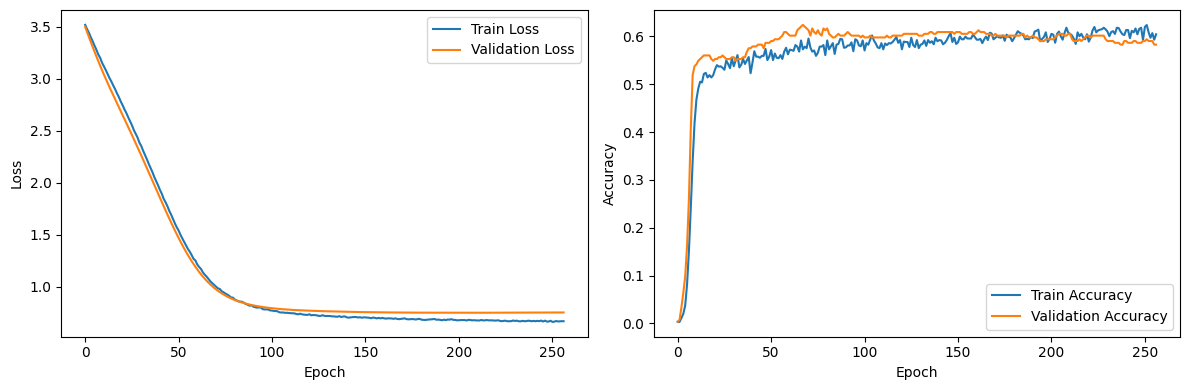


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1083, Val Loss: 3.1114, Train Acc: 0.4295, Val Acc: 0.4941
Epoch: 020, Train Loss: 2.7277, Val Loss: 2.7559, Train Acc: 0.5159, Val Acc: 0.5020
Epoch: 030, Train Loss: 2.3415, Val Loss: 2.3694, Train Acc: 0.5218, Val Acc: 0.5020
Epoch: 040, Train Loss: 1.9292, Val Loss: 1.9469, Train Acc: 0.5210, Val Acc: 0.5020
Epoch: 050, Train Loss: 1.5389, Val Loss: 1.5296, Train Acc: 0.5185, Val Acc: 0.5020
Epoch: 060, Train Loss: 1.2059, Val Loss: 1.1915, Train Acc: 0.5277, Val Acc: 0.5020
Epoch: 070, Train Loss: 0.9823, Val Loss: 0.9763, Train Acc: 0.5478, Val Acc: 0.5059
Epoch: 080, Train Loss: 0.8656, Val Loss: 0.8584, Train Acc: 0.5487, Val Acc: 0.5333
Epoch: 090, Train Loss: 0.8014, Val Loss: 0.7958, Train Acc: 0.5646, Val Acc: 0.5569
Epoch: 100, Train Loss: 0.7545, Val Loss: 0.7613, Train Acc: 0.6040, Val Acc: 0.5725
Epoch: 110, Train Loss: 0.7411, Val Loss: 0.7409, Tr

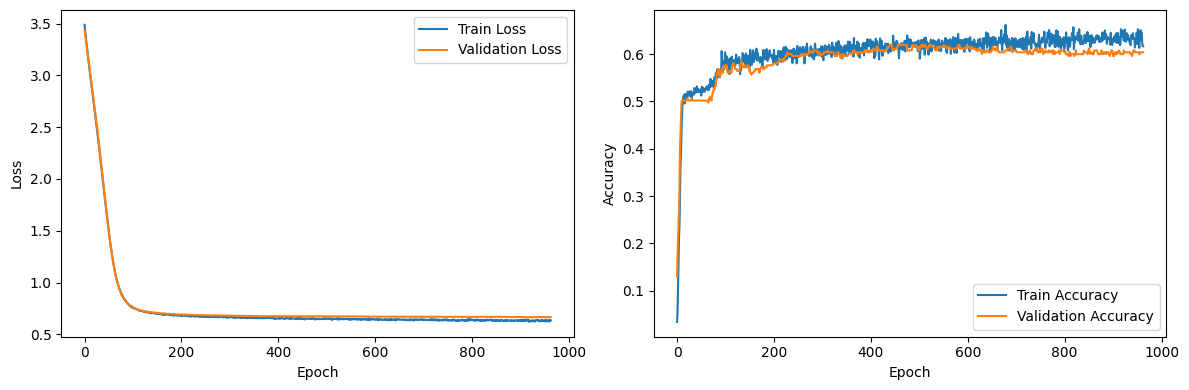


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2146, Val Loss: 3.1966, Train Acc: 0.1760, Val Acc: 0.1864
Epoch: 020, Train Loss: 2.8149, Val Loss: 2.7952, Train Acc: 0.5672, Val Acc: 0.5000
Epoch: 030, Train Loss: 2.4052, Val Loss: 2.3804, Train Acc: 0.5626, Val Acc: 0.5254
Epoch: 040, Train Loss: 1.9672, Val Loss: 1.9484, Train Acc: 0.5672, Val Acc: 0.5297
Epoch: 050, Train Loss: 1.5410, Val Loss: 1.5317, Train Acc: 0.5780, Val Acc: 0.5381
Epoch: 060, Train Loss: 1.2010, Val Loss: 1.1965, Train Acc: 0.5808, Val Acc: 0.5466
Epoch: 070, Train Loss: 0.9786, Val Loss: 0.9825, Train Acc: 0.5835, Val Acc: 0.5339
Epoch: 080, Train Loss: 0.8579, Val Loss: 0.8652, Train Acc: 0.5762, Val Acc: 0.5508
Epoch: 090, Train Loss: 0.7943, Val Loss: 0.8037, Train Acc: 0.5799, Val Acc: 0.5551
Epoch: 100, Train Loss: 0.7573, Val Loss: 0.7710, Train Acc: 0.5762, Val Acc: 0.5381
Epoch: 110, Train Loss: 0.7403, Val Loss: 0.7526, Tr

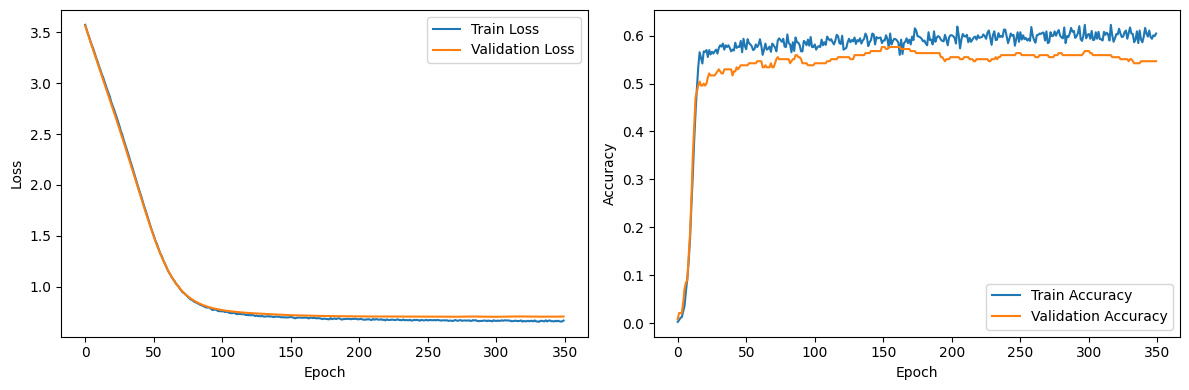


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0797, Val Loss: 3.0292, Train Acc: 0.3819, Val Acc: 0.4358
Epoch: 020, Train Loss: 2.6651, Val Loss: 2.5828, Train Acc: 0.4990, Val Acc: 0.5000
Epoch: 030, Train Loss: 2.2396, Val Loss: 2.1540, Train Acc: 0.5217, Val Acc: 0.5092
Epoch: 040, Train Loss: 1.8069, Val Loss: 1.7379, Train Acc: 0.5404, Val Acc: 0.4954
Epoch: 050, Train Loss: 1.4214, Val Loss: 1.3712, Train Acc: 0.5118, Val Acc: 0.4954
Epoch: 060, Train Loss: 1.1216, Val Loss: 1.1043, Train Acc: 0.5325, Val Acc: 0.4908
Epoch: 070, Train Loss: 0.9436, Val Loss: 0.9434, Train Acc: 0.5689, Val Acc: 0.4862
Epoch: 080, Train Loss: 0.8582, Val Loss: 0.8543, Train Acc: 0.5384, Val Acc: 0.5138
Epoch: 090, Train Loss: 0.7925, Val Loss: 0.8046, Train Acc: 0.5472, Val Acc: 0.5092
Epoch: 100, Train Loss: 0.7658, Val Loss: 0.7759, Train Acc: 0.5551, Val Acc: 0.4954
Epoch: 110, Train Loss: 0.7474, Val Loss: 0.7583, Tr

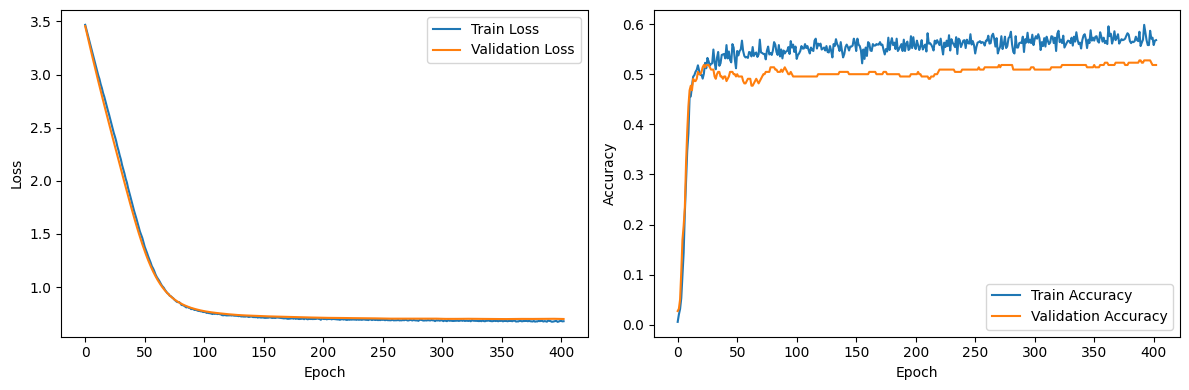


========== Run 14 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1473, Val Loss: 3.0662, Train Acc: 0.3255, Val Acc: 0.4286
Epoch: 020, Train Loss: 2.7431, Val Loss: 2.6421, Train Acc: 0.5302, Val Acc: 0.5564
Epoch: 030, Train Loss: 2.3261, Val Loss: 2.2355, Train Acc: 0.5278, Val Acc: 0.5489
Epoch: 040, Train Loss: 1.9022, Val Loss: 1.8218, Train Acc: 0.5310, Val Acc: 0.5451
Epoch: 050, Train Loss: 1.5075, Val Loss: 1.4370, Train Acc: 0.5560, Val Acc: 0.5639
Epoch: 060, Train Loss: 1.1926, Val Loss: 1.1391, Train Acc: 0.5407, Val Acc: 0.5677
Epoch: 070, Train Loss: 0.9905, Val Loss: 0.9540, Train Acc: 0.5600, Val Acc: 0.5789
Epoch: 080, Train Loss: 0.8701, Val Loss: 0.8548, Train Acc: 0.5721, Val Acc: 0.5940
Epoch: 090, Train Loss: 0.8044, Val Loss: 0.8037, Train Acc: 0.5818, Val Acc: 0.6015
Epoch: 100, Train Loss: 0.7636, Val Loss: 0.7745, Train Acc: 0.5721, Val Acc: 0.6128
Epoch: 110, Train Los

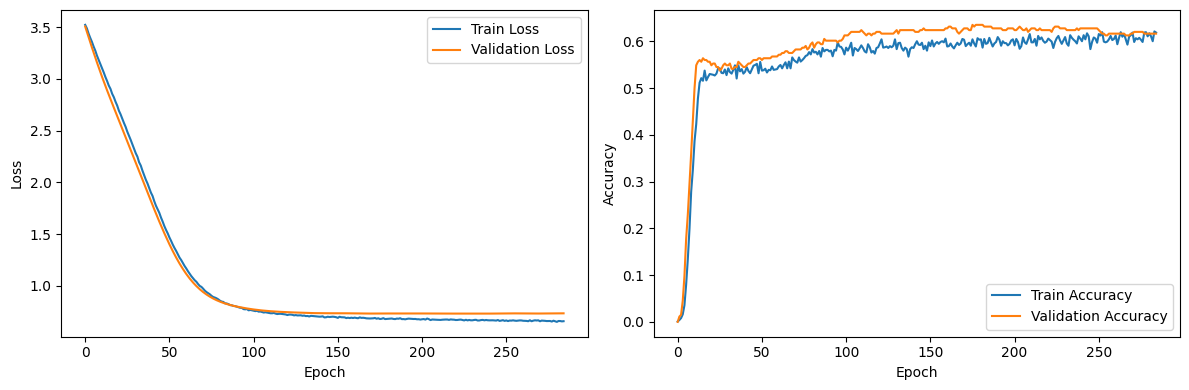


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2785, Val Loss: 3.3069, Train Acc: 0.1720, Val Acc: 0.1765
Epoch: 020, Train Loss: 2.9604, Val Loss: 3.0146, Train Acc: 0.4975, Val Acc: 0.4902
Epoch: 030, Train Loss: 2.6261, Val Loss: 2.6897, Train Acc: 0.5034, Val Acc: 0.4863
Epoch: 040, Train Loss: 2.2531, Val Loss: 2.3170, Train Acc: 0.5235, Val Acc: 0.4784
Epoch: 050, Train Loss: 1.8751, Val Loss: 1.9064, Train Acc: 0.5076, Val Acc: 0.5059
Epoch: 060, Train Loss: 1.4828, Val Loss: 1.5011, Train Acc: 0.5235, Val Acc: 0.5255
Epoch: 070, Train Loss: 1.1660, Val Loss: 1.1737, Train Acc: 0.5076, Val Acc: 0.5333
Epoch: 080, Train Loss: 0.9615, Val Loss: 0.9659, Train Acc: 0.5461, Val Acc: 0.5373
Epoch: 090, Train Loss: 0.8357, Val Loss: 0.8540, Train Acc: 0.5545, Val Acc: 0.5608
Epoch: 100, Train Loss: 0.7820, Val Loss: 0.7955, Train Acc: 0.5797, Val Acc: 0.5333
Epoch: 110, Train Loss: 0.7527, Val Loss: 0.7632, Tr

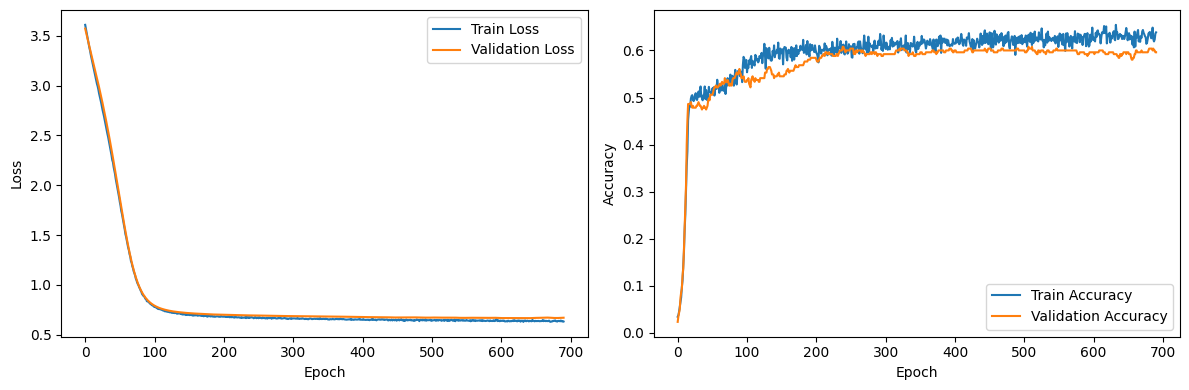


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0739, Val Loss: 3.0206, Train Acc: 0.4746, Val Acc: 0.4873
Epoch: 020, Train Loss: 2.7009, Val Loss: 2.6426, Train Acc: 0.5481, Val Acc: 0.5000
Epoch: 030, Train Loss: 2.3229, Val Loss: 2.2676, Train Acc: 0.5445, Val Acc: 0.5042
Epoch: 040, Train Loss: 1.9121, Val Loss: 1.8731, Train Acc: 0.5499, Val Acc: 0.5381
Epoch: 050, Train Loss: 1.5167, Val Loss: 1.4869, Train Acc: 0.5581, Val Acc: 0.5466
Epoch: 060, Train Loss: 1.1863, Val Loss: 1.1703, Train Acc: 0.5762, Val Acc: 0.5466
Epoch: 070, Train Loss: 0.9730, Val Loss: 0.9661, Train Acc: 0.5799, Val Acc: 0.5508
Epoch: 080, Train Loss: 0.8473, Val Loss: 0.8564, Train Acc: 0.5717, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.7884, Val Loss: 0.8000, Train Acc: 0.5980, Val Acc: 0.5678
Epoch: 100, Train Loss: 0.7558, Val Loss: 0.7705, Train Acc: 0.5762, Val Acc: 0.5593
Epoch: 110, Train Loss: 0.7329, Val Loss: 0.7535, Tr

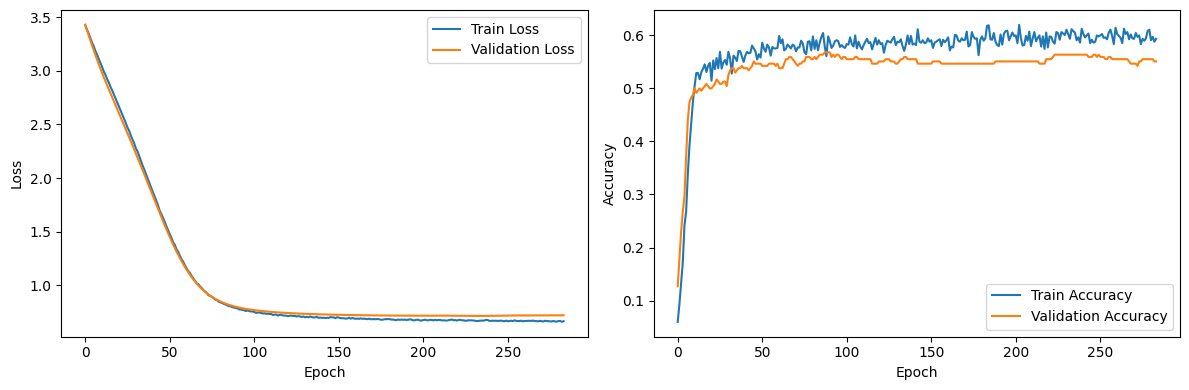


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1408, Val Loss: 3.0347, Train Acc: 0.2244, Val Acc: 0.2798
Epoch: 020, Train Loss: 2.7959, Val Loss: 2.6825, Train Acc: 0.5089, Val Acc: 0.4908
Epoch: 030, Train Loss: 2.4452, Val Loss: 2.3389, Train Acc: 0.5128, Val Acc: 0.4771
Epoch: 040, Train Loss: 2.0765, Val Loss: 1.9801, Train Acc: 0.5226, Val Acc: 0.4954
Epoch: 050, Train Loss: 1.6921, Val Loss: 1.6182, Train Acc: 0.5335, Val Acc: 0.5000
Epoch: 060, Train Loss: 1.3433, Val Loss: 1.2970, Train Acc: 0.5404, Val Acc: 0.4862
Epoch: 070, Train Loss: 1.0926, Val Loss: 1.0601, Train Acc: 0.5344, Val Acc: 0.5275
Epoch: 080, Train Loss: 0.9322, Val Loss: 0.9158, Train Acc: 0.5610, Val Acc: 0.4771
Epoch: 090, Train Loss: 0.8370, Val Loss: 0.8370, Train Acc: 0.5472, Val Acc: 0.4862
Epoch: 100, Train Loss: 0.7862, Val Loss: 0.7942, Train Acc: 0.5561, Val Acc: 0.4954
Epoch: 110, Train Loss: 0.7634, Val Loss: 0.7694, Tr

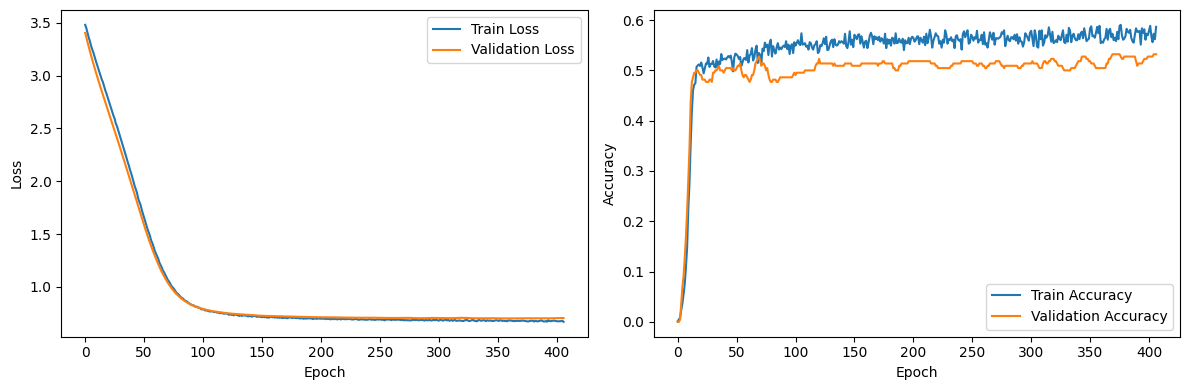


========== Final Summary ==========

Year: 2019
  Avg Test Accuracy: 0.6300 ± 0.0102
  Avg Test F1 Score: 0.6299 ± 0.0102
 Train Accuracy: 0.5921 ± 0.0084
Year: 2020
  Avg Test Accuracy: 0.5611 ± 0.0161
  Avg Test F1 Score: 0.5610 ± 0.0162
 Train Accuracy: 0.6221 ± 0.0126
Year: 2021
  Avg Test Accuracy: 0.5395 ± 0.0117
  Avg Test F1 Score: 0.5393 ± 0.0118
 Train Accuracy: 0.5974 ± 0.0090
Year: 2022
  Avg Test Accuracy: 0.5396 ± 0.0116
  Avg Test F1 Score: 0.5381 ± 0.0115
 Train Accuracy: 0.5608 ± 0.0110


In [6]:
if __name__ == "__main__":

    years = [2019, 2020, 2021, 2022]
    metric = 'revenue'

    # To store results for each year across 10 runs
    aggregate_results = {year: {'acc': [], 'f1': [], 'time': [], 'epochs': [], 'best_train_acc': []} for year in years}
    param = {
            "hidden_channels": 64,
            "out_channels": 32,
            "num_heads": 4,
            "lr": 0.0009,
            "weight_decay": 5e-4,
            "epochs": 1000,
            "patience": 50
        }

    #Add optuna code section here
    best_params_per_year = {}
    # for year in years:
    #     print(f"\nRunning Optuna optimization for year {year}...\n")
    
    #     study = optuna.create_study(direction="maximize")
    #     study.optimize(lambda trial: objective(trial, year, metric), n_trials=15)
    
    #     print(f"Best trial for year {year}: {study.best_trial.value}")
    #     print("Best hyperparameters:", study.best_params)

    #     best_params_per_year[year] = study.best_params
    
    for i in range(1, 15):
        print(f"\n========== Run {i} ==========\n")
        for year in years:
            # param = best_params_per_year[year]
            print(f"\nRunning experiment for year {year}...\n")
            results = run_experiment(year, metric, **param)
            # Store individual run metrics
            aggregate_results[year]['acc'].append(results['test_acc'])
            aggregate_results[year]['f1'].append(results['test_f1'])
            aggregate_results[year]['time'].append(results['training_time'])
            aggregate_results[year]['epochs'].append(results['epochs_run'])
            aggregate_results[year]['best_train_acc'].append(results['best_train_acc'])

    print("\n========== Final Summary ==========\n")
    for year in years:
        acc_mean = np.mean(aggregate_results[year]['acc'])
        acc_std = np.std(aggregate_results[year]['acc'])
        f1_mean = np.mean(aggregate_results[year]['f1'])
        f1_std = np.std(aggregate_results[year]['f1'])
        train_acc_mean = np.mean(aggregate_results[year]['best_train_acc'])
        train_acc_std = np.std(aggregate_results[year]['best_train_acc'])

        print(f"Year: {year}")
        print(f"  Avg Test Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
        print(f"  Avg Test F1 Score: {f1_mean:.4f} ± {f1_std:.4f}")
        print(f" Train Accuracy: {train_acc_mean:.4f} ± {train_acc_std:.4f}")